# Score Analysis

This notebook loads `scores.csv` files from experiment directories and visualizes the performance of different models.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [6]:
# Run the load cell first, then uncomment the next line to inspect test_set values
# print(df_scores['test_set'].unique())


== Test set: test ==


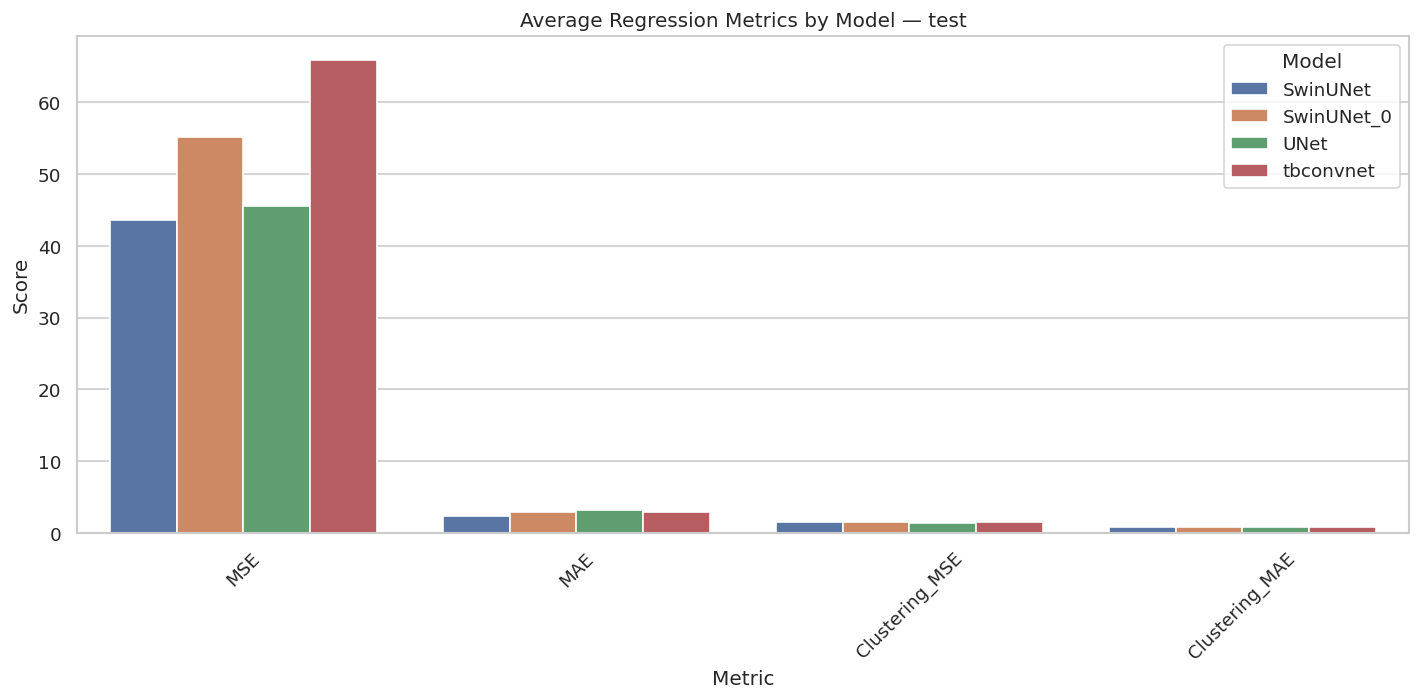

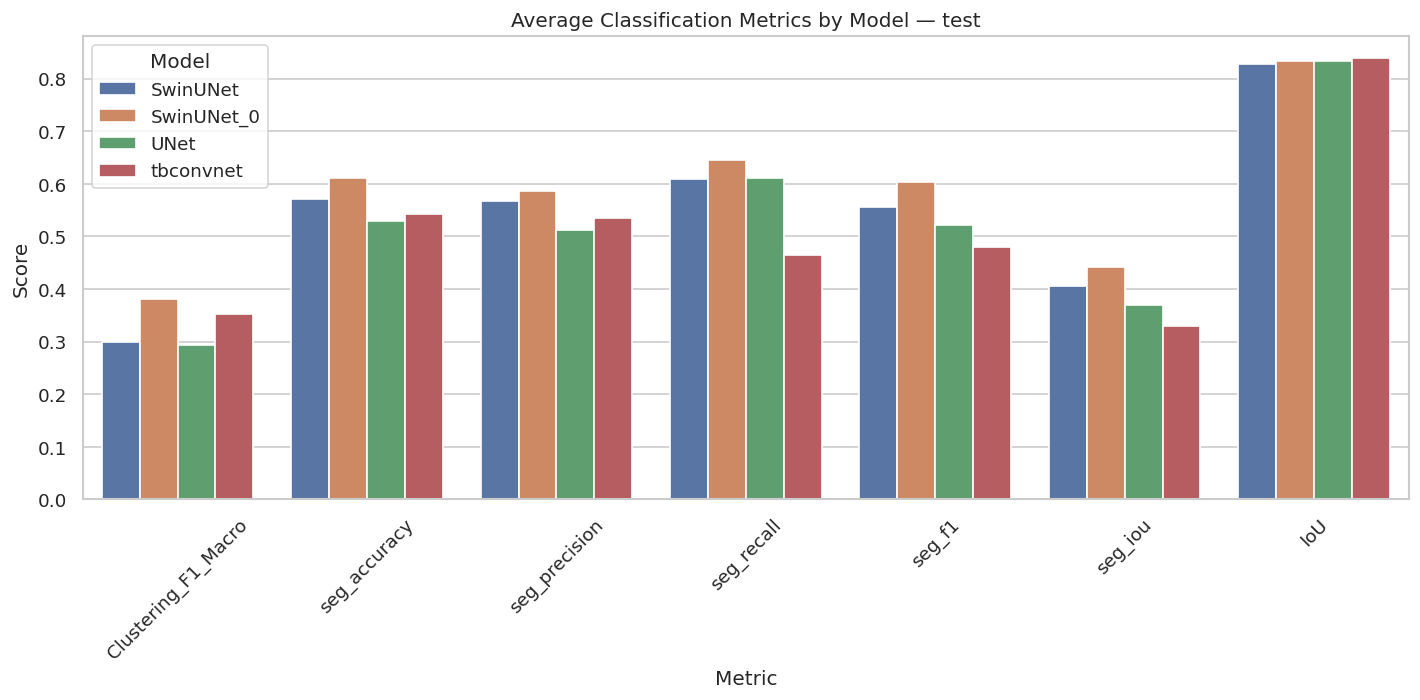


== Test set: train ==


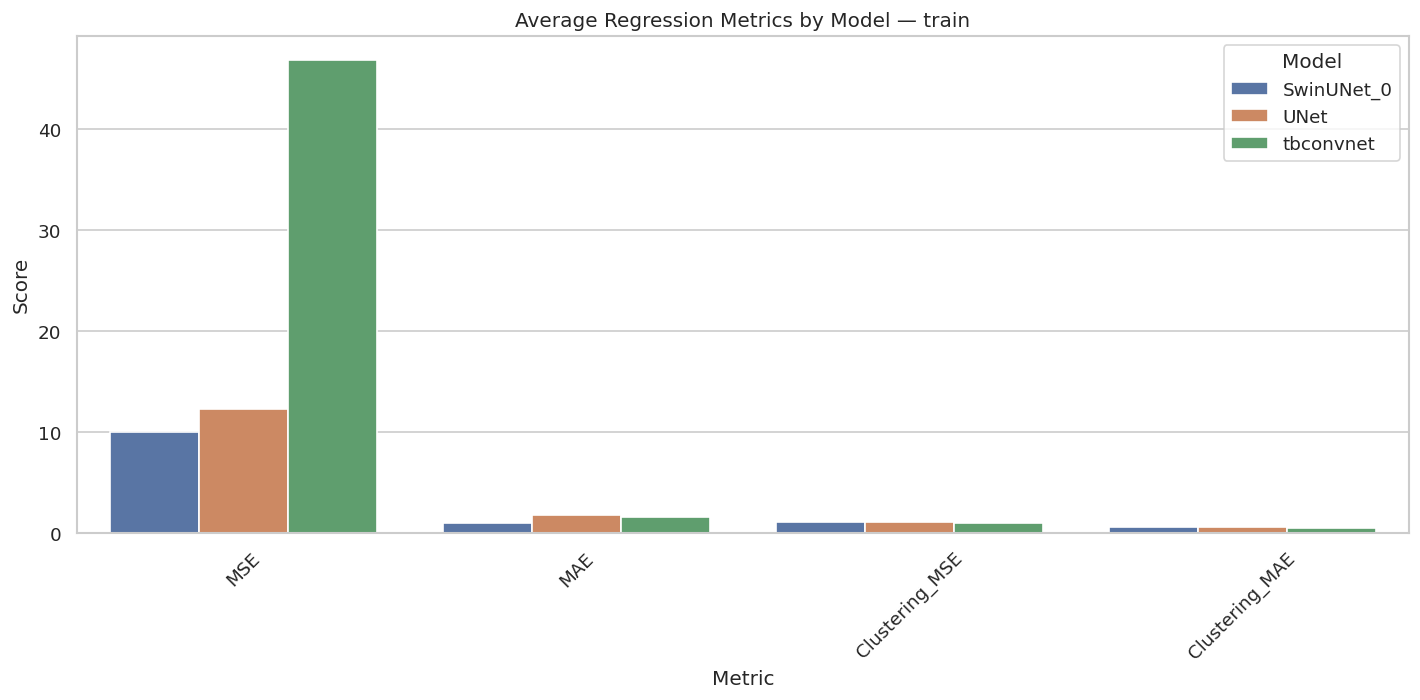

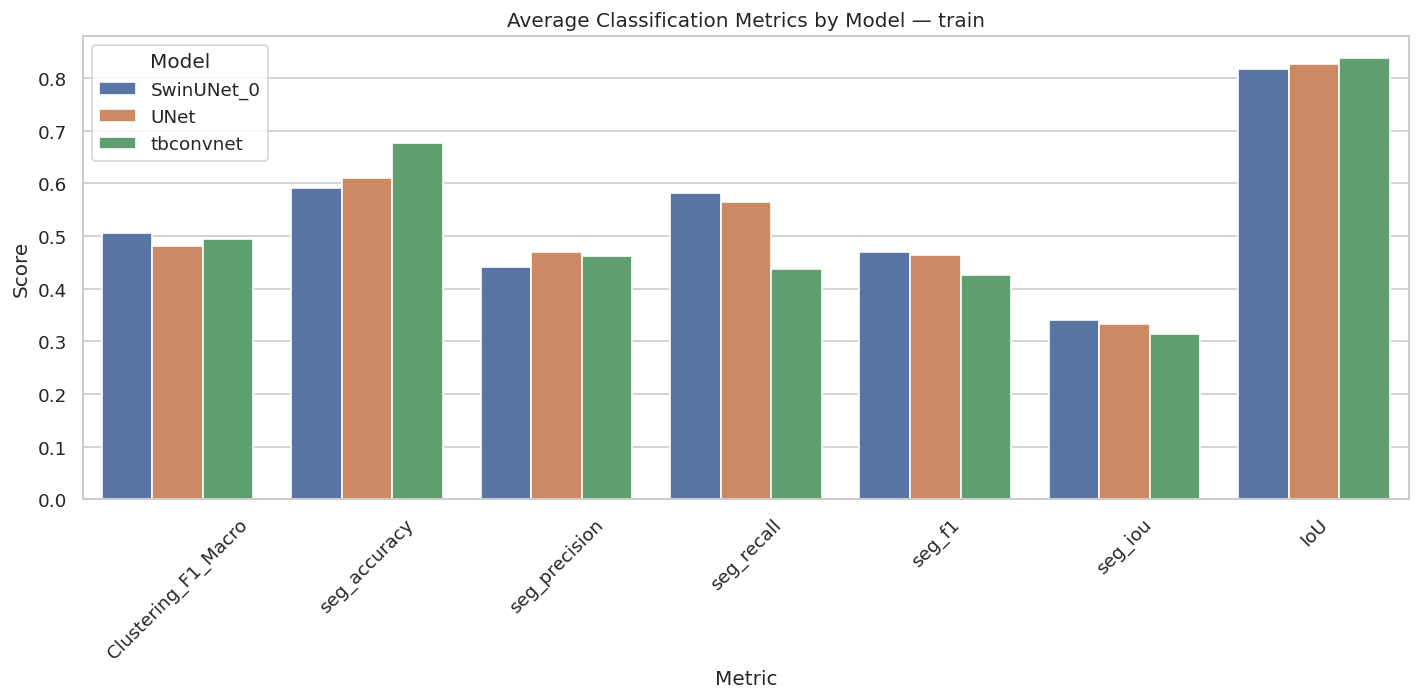

In [7]:
# Configuration: adjust paths to your environment
BASE_DIR = '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/LearnedSegmentation/Experiments'
TARGET_EXPERIMENT = 'target_risk_risk_scale_3_tol_0.3_attempt_3_reduce_4_ncluster_10'
SEARCH_DIR = os.path.join(BASE_DIR, TARGET_EXPERIMENT)

# Function to load all scores.csv under the search directory
def load_scores(search_dir):
    all_scores = []
    for root, dirs, files in os.walk(search_dir):
        for f in files:
            if f == 'scores.csv':
                file_path = os.path.join(root, f)
                model_name = os.path.basename(os.path.dirname(file_path))
                try:
                    df = pd.read_csv(file_path)
                    df['Model'] = model_name
                    all_scores.append(df)
                except Exception as e:
                    print(f'Error loading {file_path}: {e}')
    if not all_scores:
        print('No scores.csv files found.')
        return pd.DataFrame()
    return pd.concat(all_scores, ignore_index=True)

# Load dataframes
df_scores = load_scores(SEARCH_DIR)
df_scores.head()

# Metrics provided by user
regression_metrics = ['MSE', 'MAE', 'Clustering_MSE', 'Clustering_MAE']
classification_metrics = ['Clustering_F1_Macro', 'seg_accuracy', 'seg_precision', 'seg_recall', 'seg_f1', 'seg_iou', 'IoU']
# Keep only existing columns
regression_metrics = [m for m in regression_metrics if m in df_scores.columns]
classification_metrics = [m for m in classification_metrics if m in df_scores.columns]

# For each test_set, plot regression and classification averages separately
for test_set in df_scores['test_set'].unique():
    df_ts = df_scores[df_scores['test_set'] == test_set]
    print(f'\n== Test set: {test_set} ==')

    if regression_metrics:
        avg_reg = df_ts.groupby('Model')[regression_metrics].mean().reset_index()
        if not avg_reg.empty:
            avg_reg_melted = avg_reg.melt(id_vars='Model', var_name='Metric', value_name='Score')
            plt.figure(figsize=(12, 6))
            sns.barplot(data=avg_reg_melted, x='Metric', y='Score', hue='Model')
            plt.title(f'Average Regression Metrics by Model — {test_set}')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

    if classification_metrics:
        avg_clf = df_ts.groupby('Model')[classification_metrics].mean().reset_index()
        if not avg_clf.empty:
            avg_clf_melted = avg_clf.melt(id_vars='Model', var_name='Metric', value_name='Score')
            plt.figure(figsize=(12, 6))
            sns.barplot(data=avg_clf_melted, x='Metric', y='Score', hue='Model')
            plt.title(f'Average Classification Metrics by Model — {test_set}')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

## Per-Department Performance Analysis


-- Per-department plots for test_set: test --


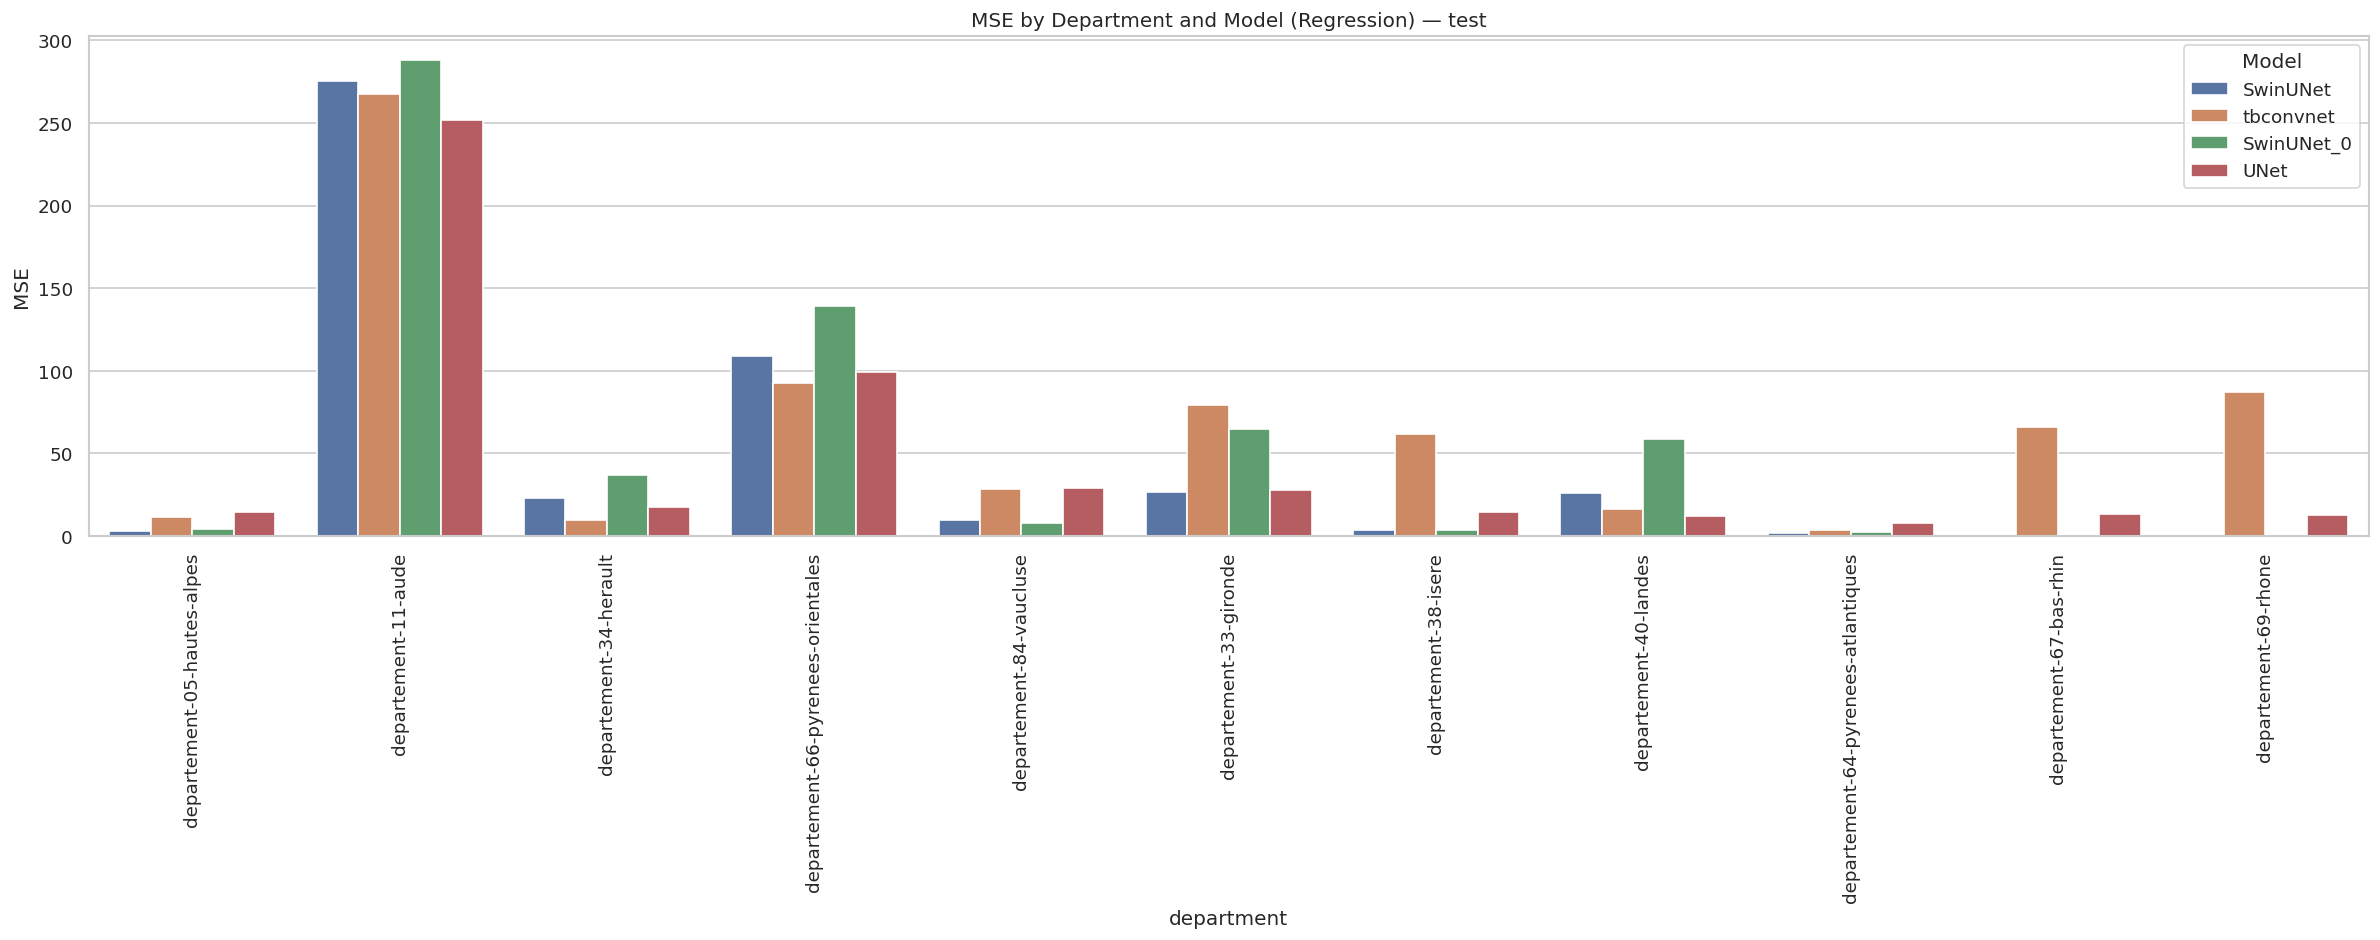

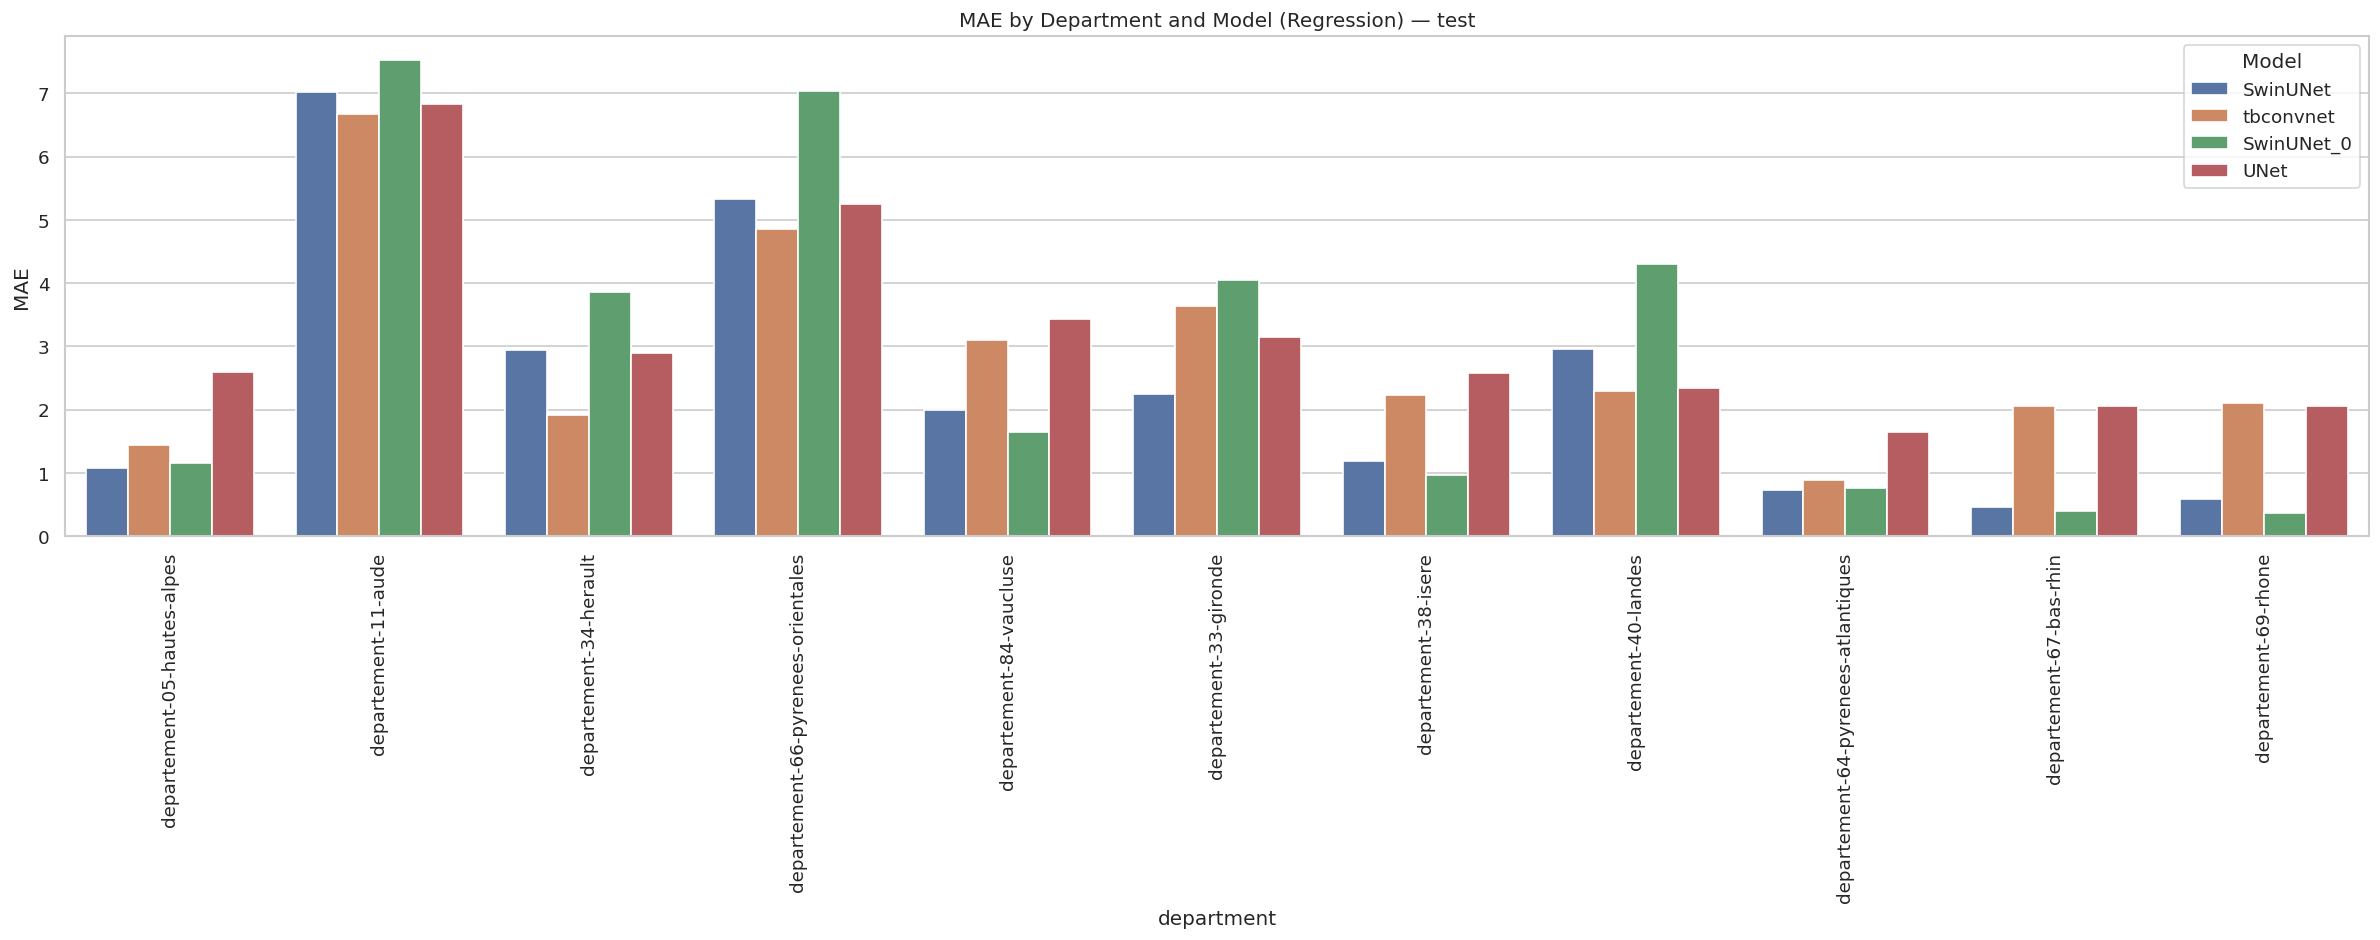

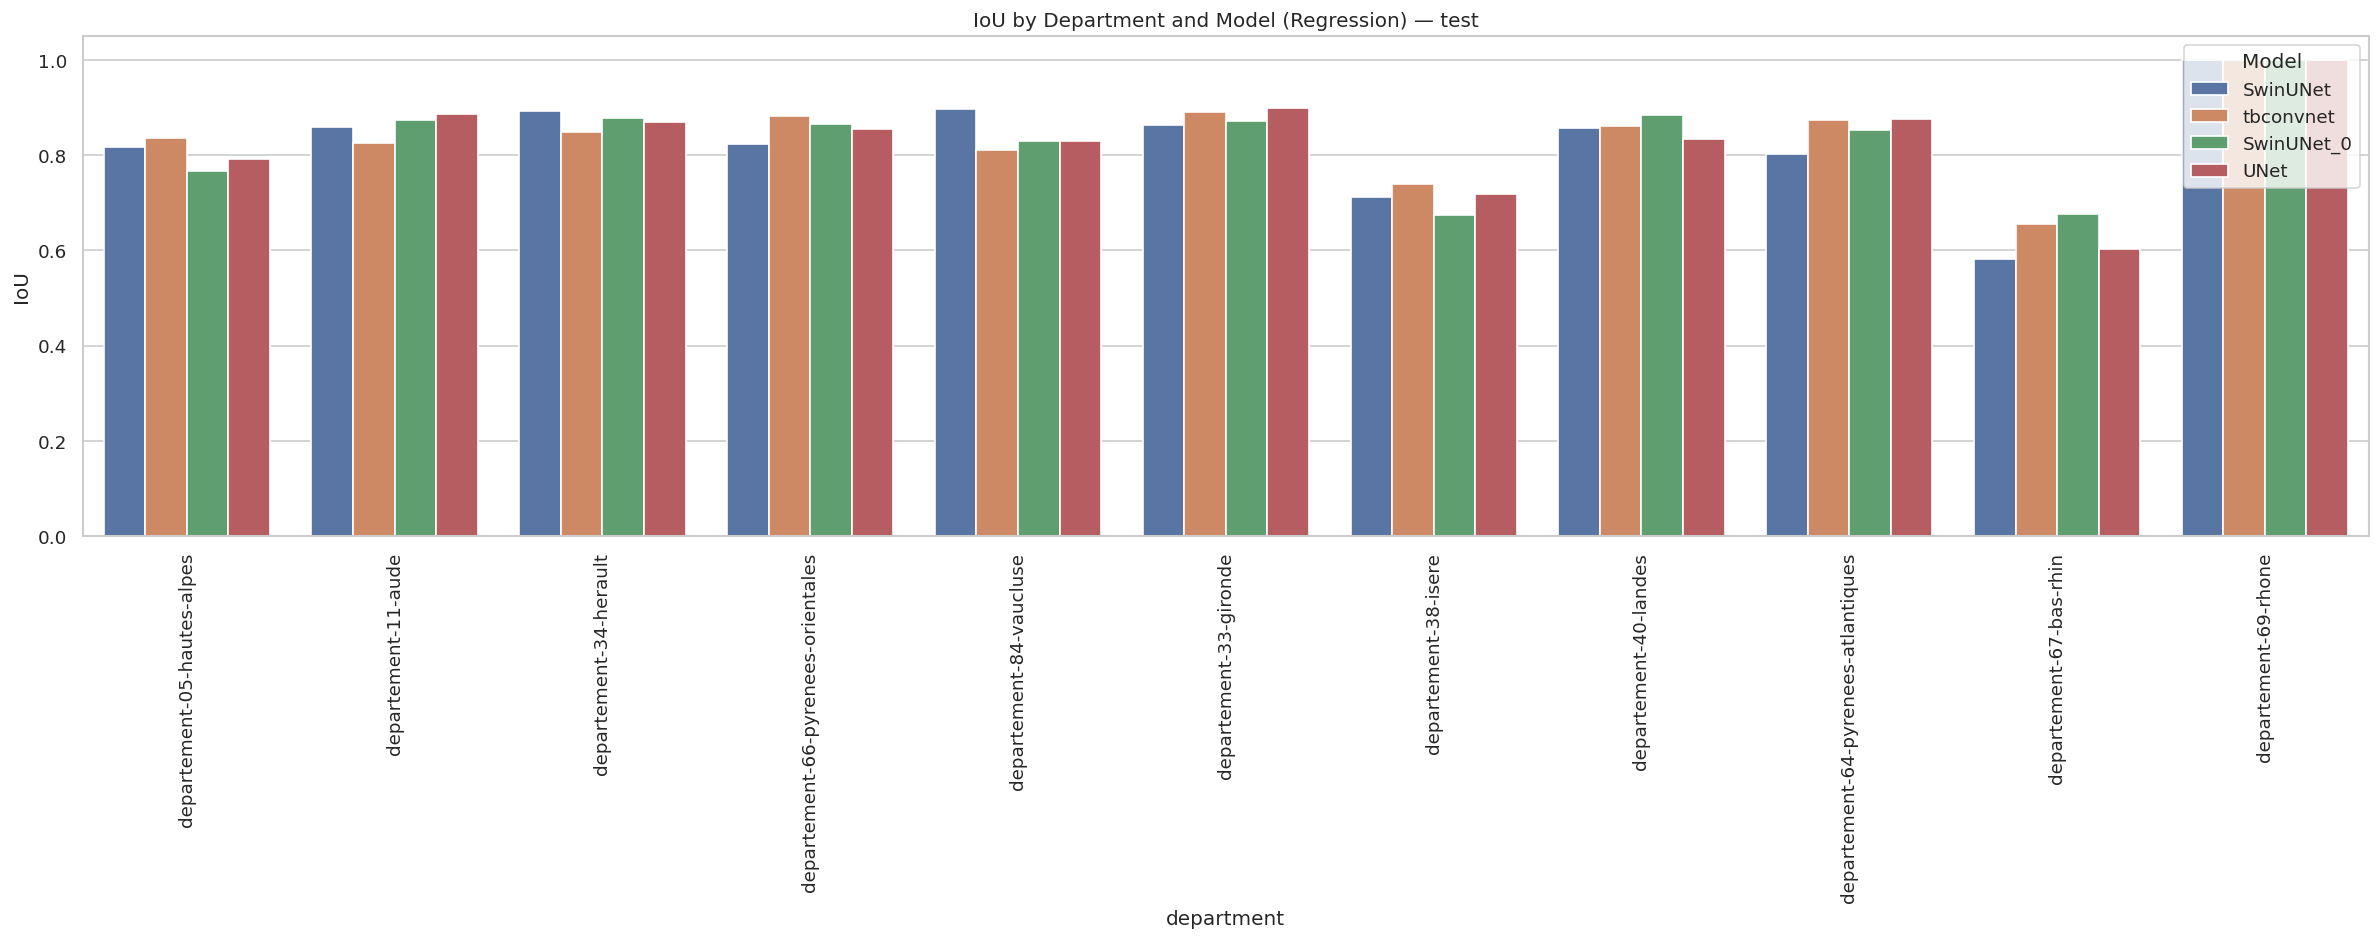

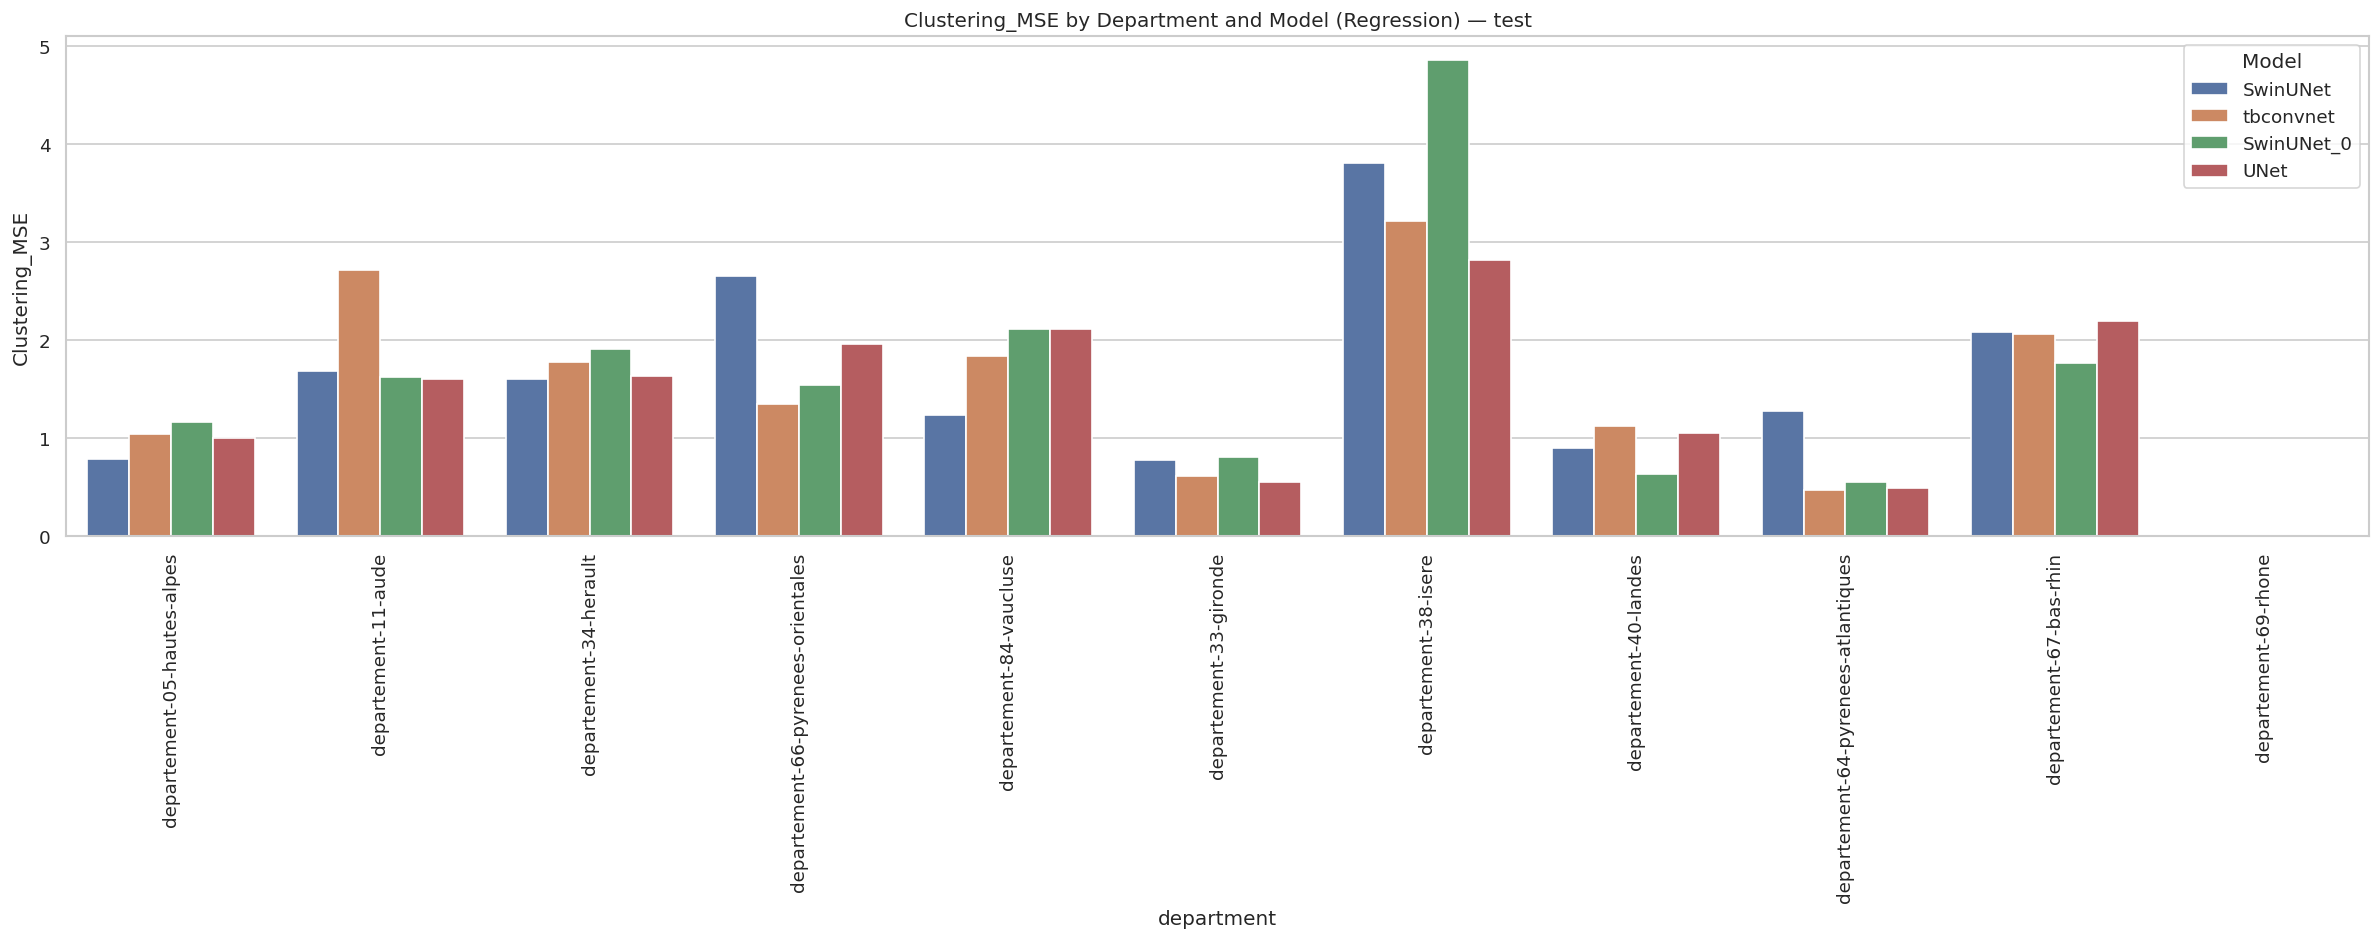

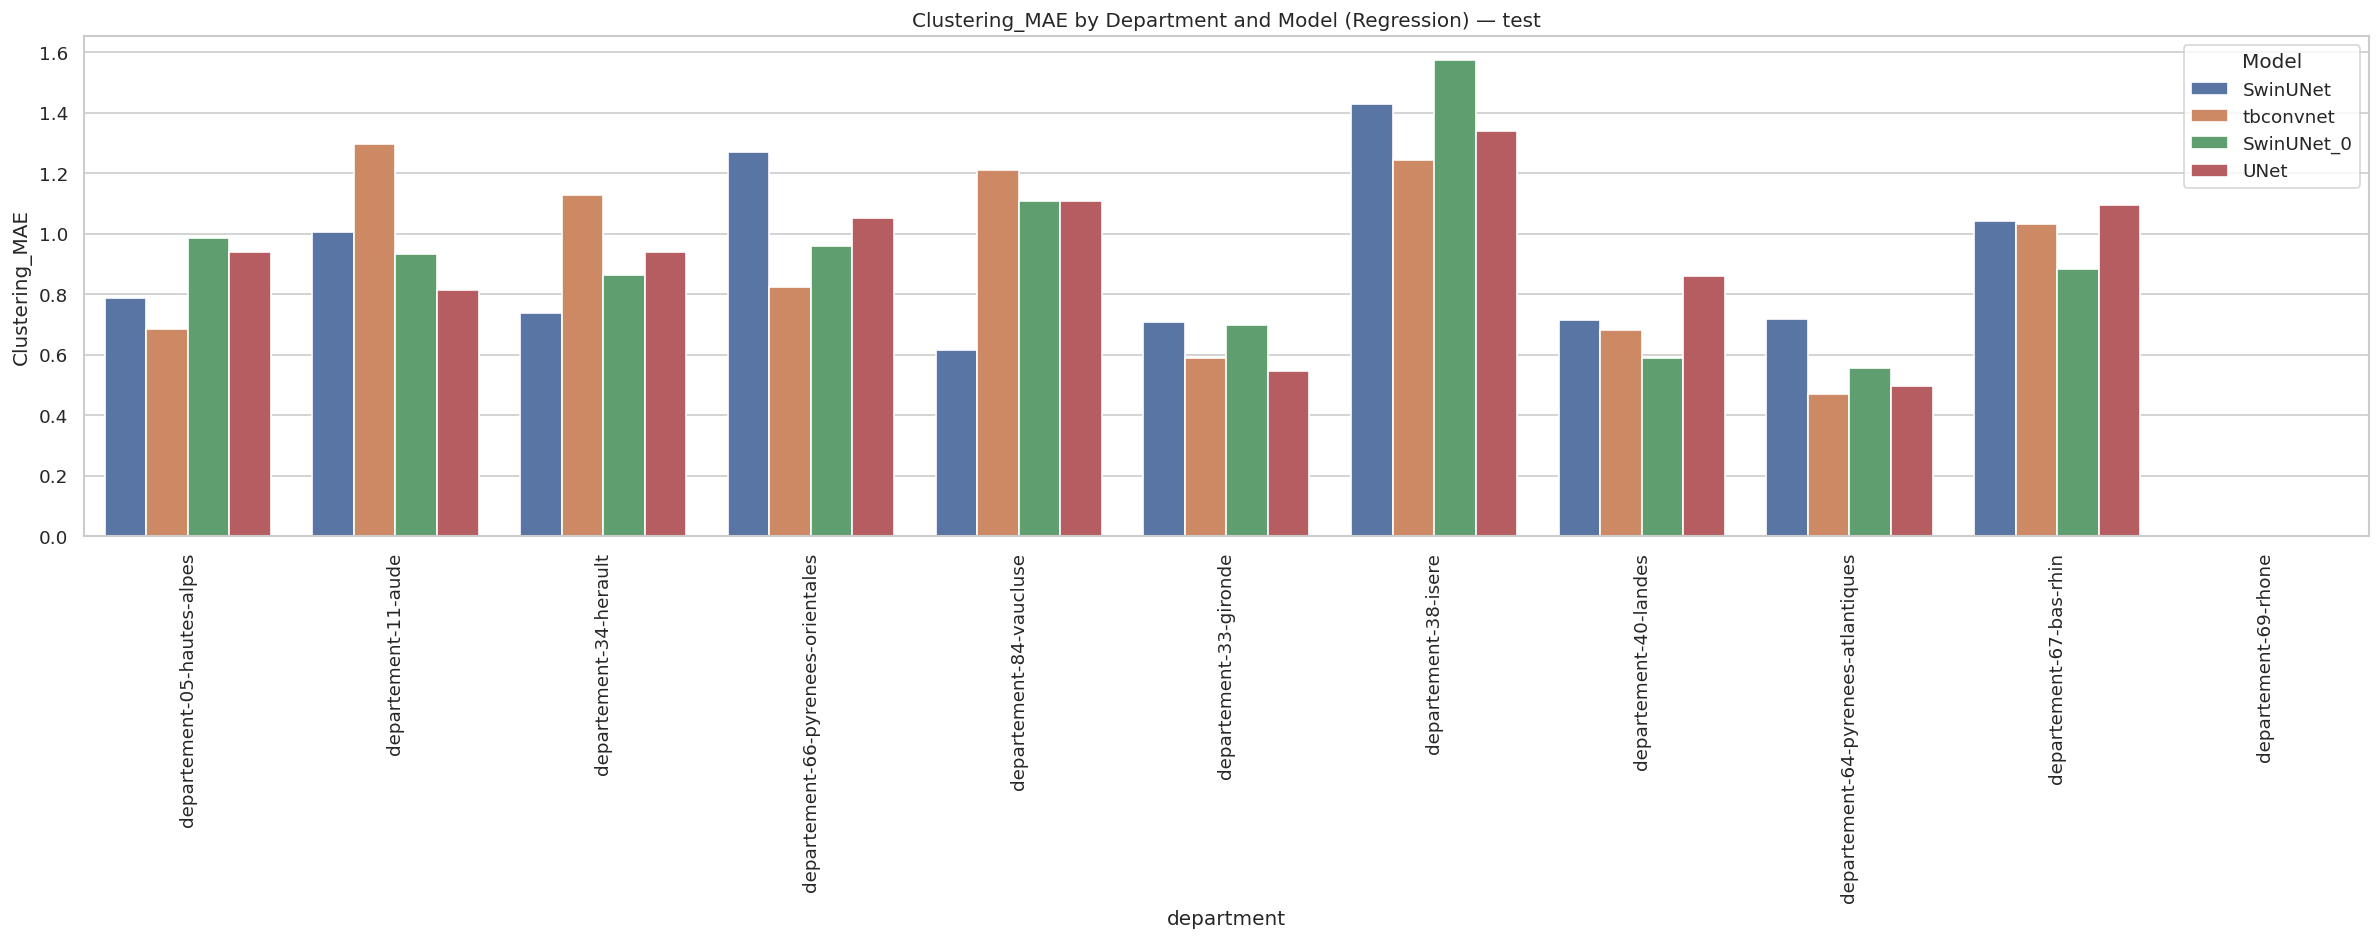

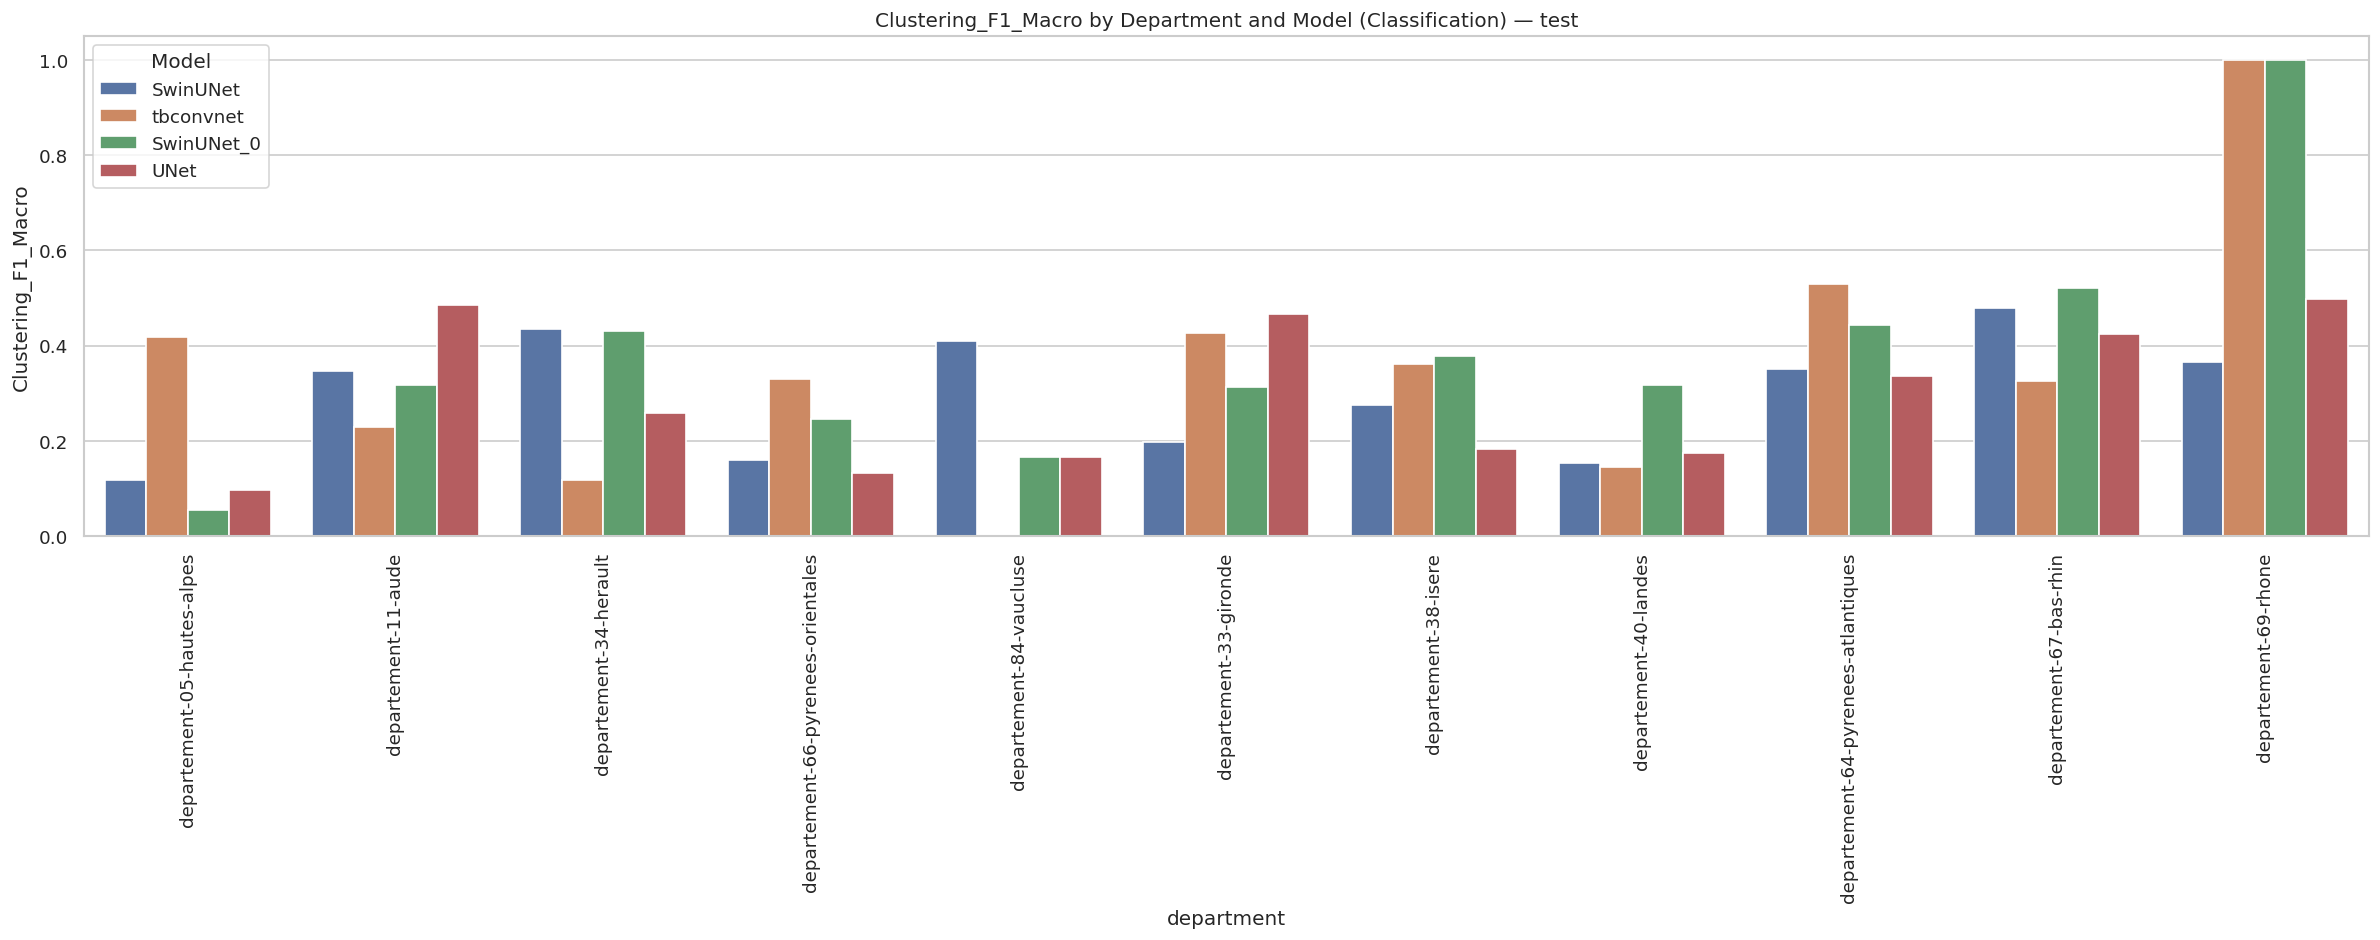

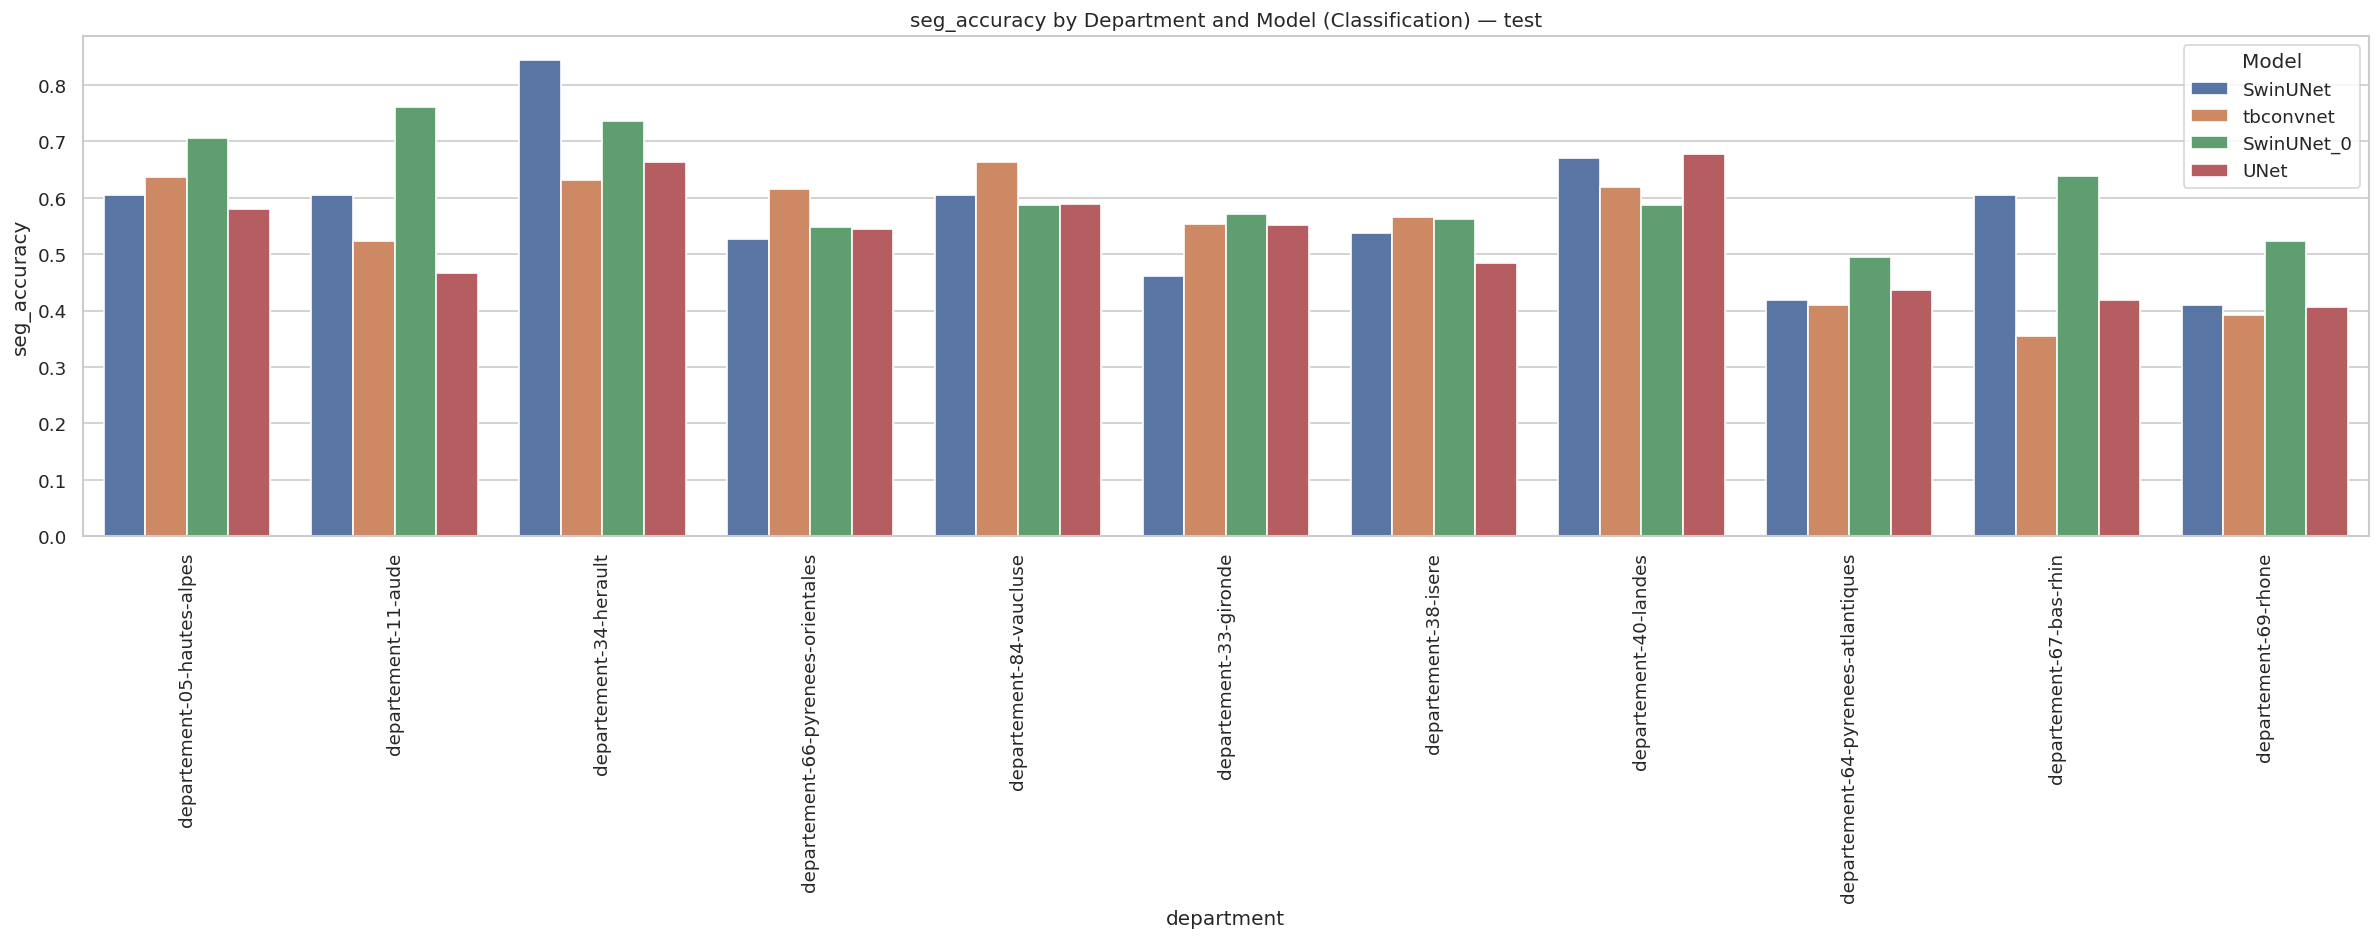

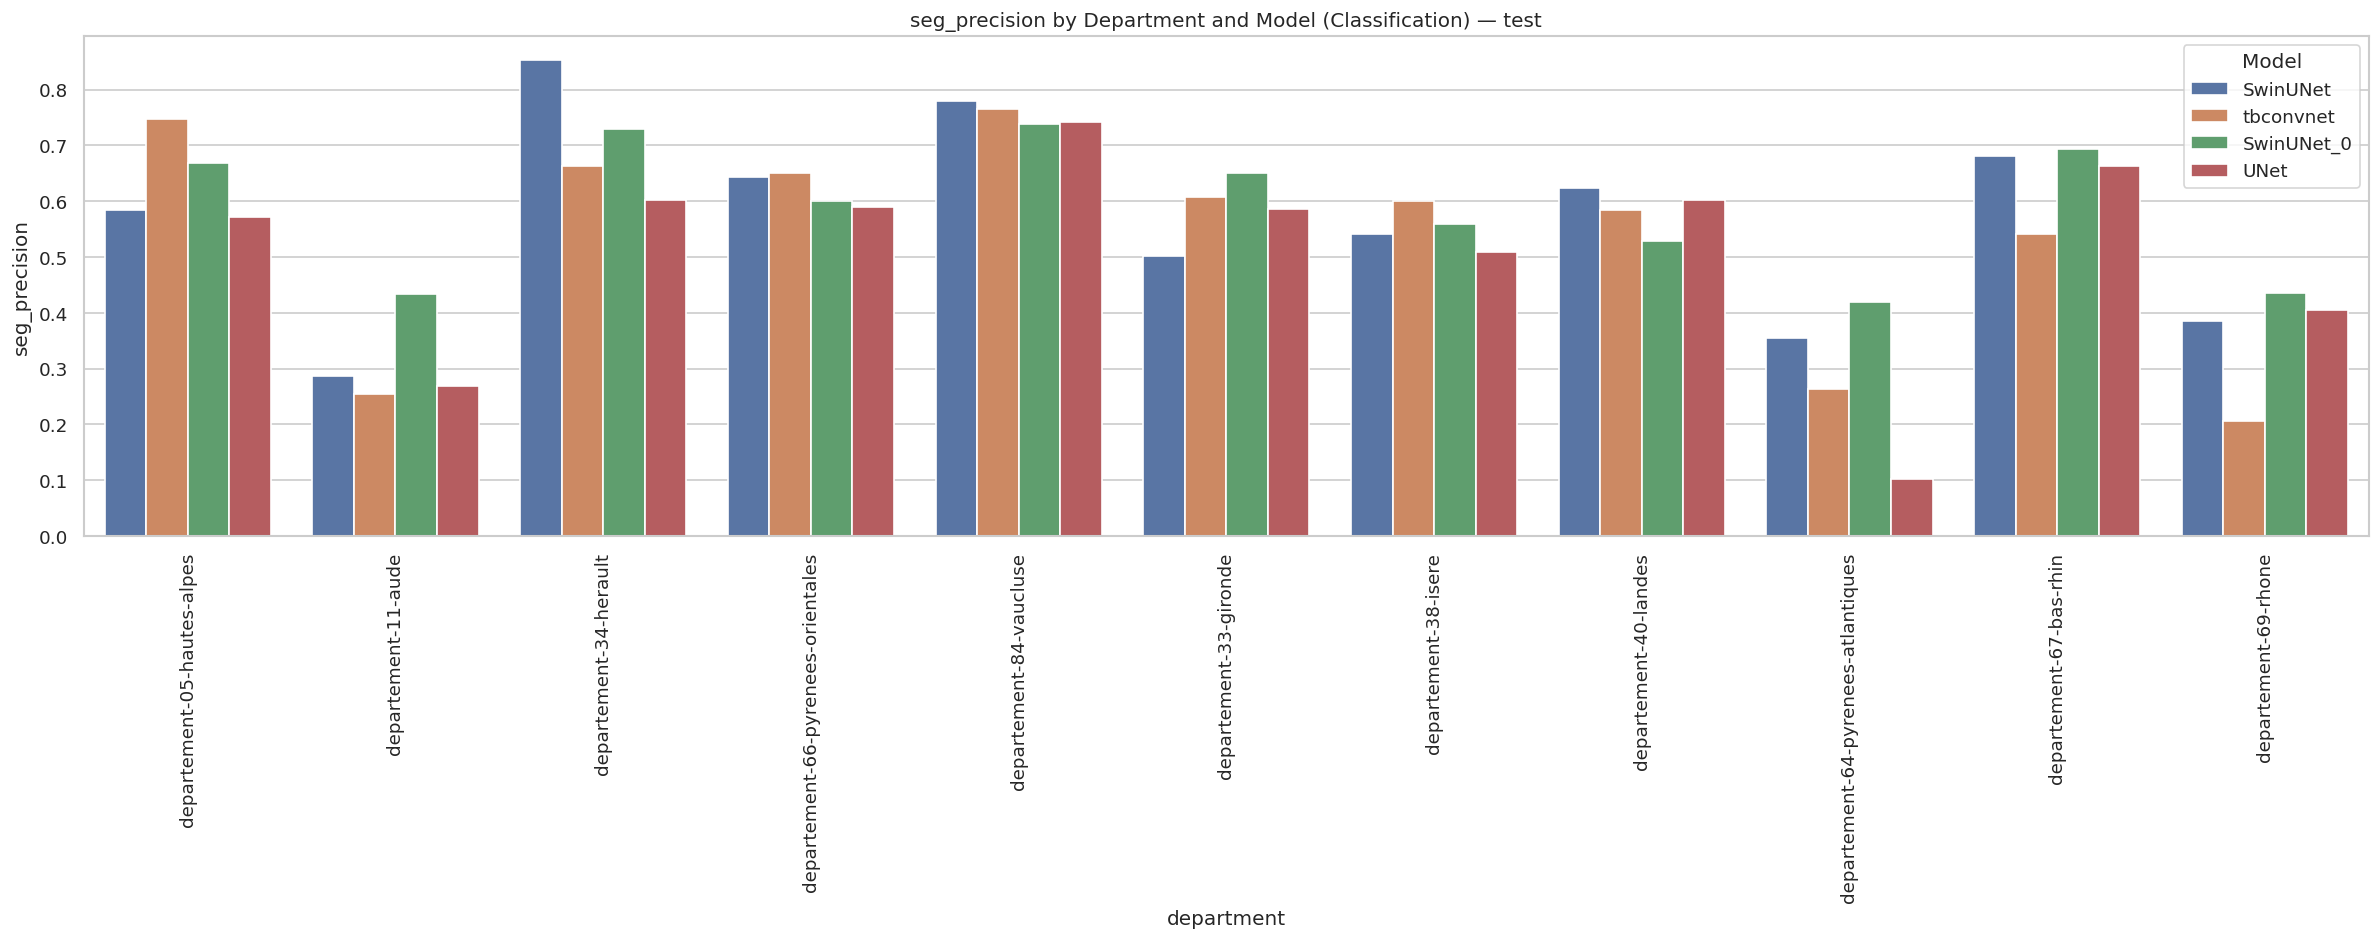

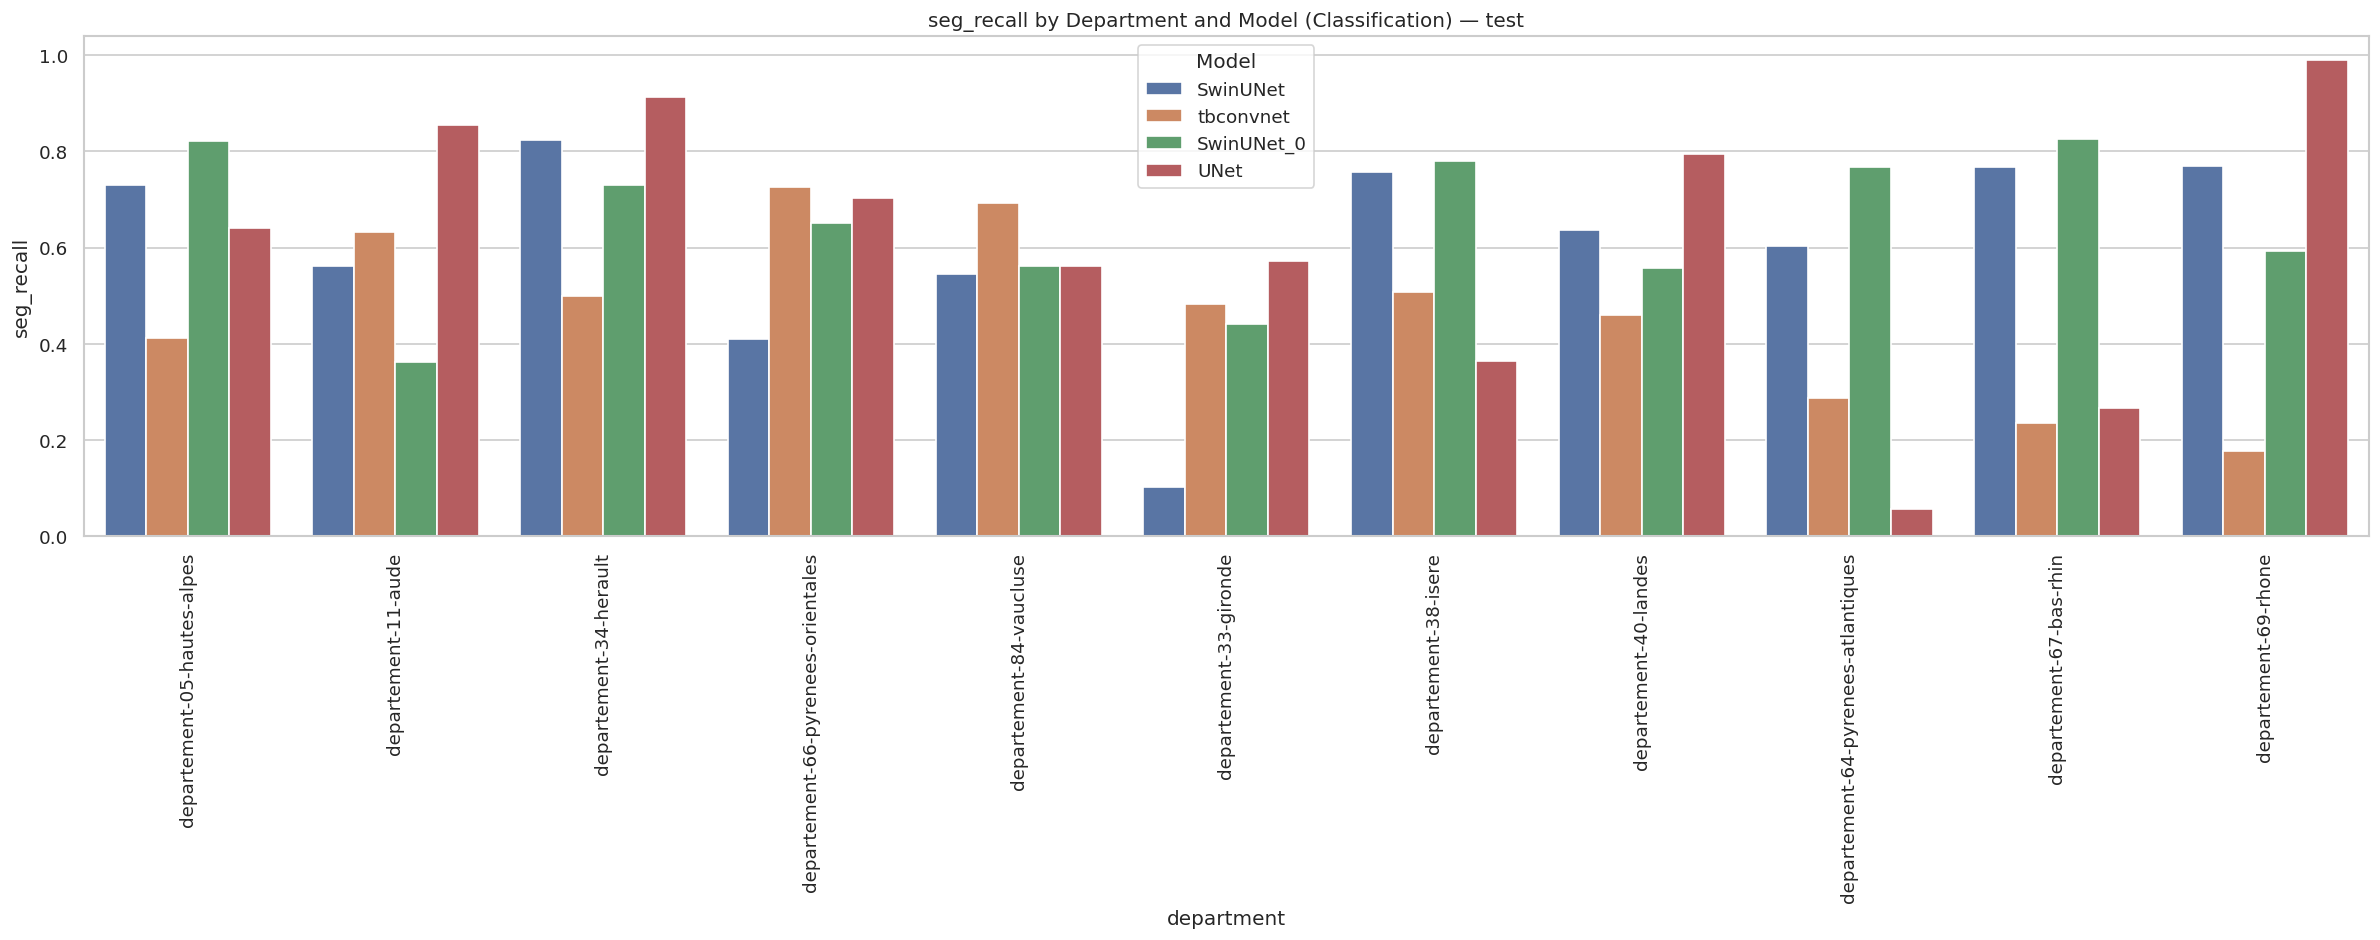

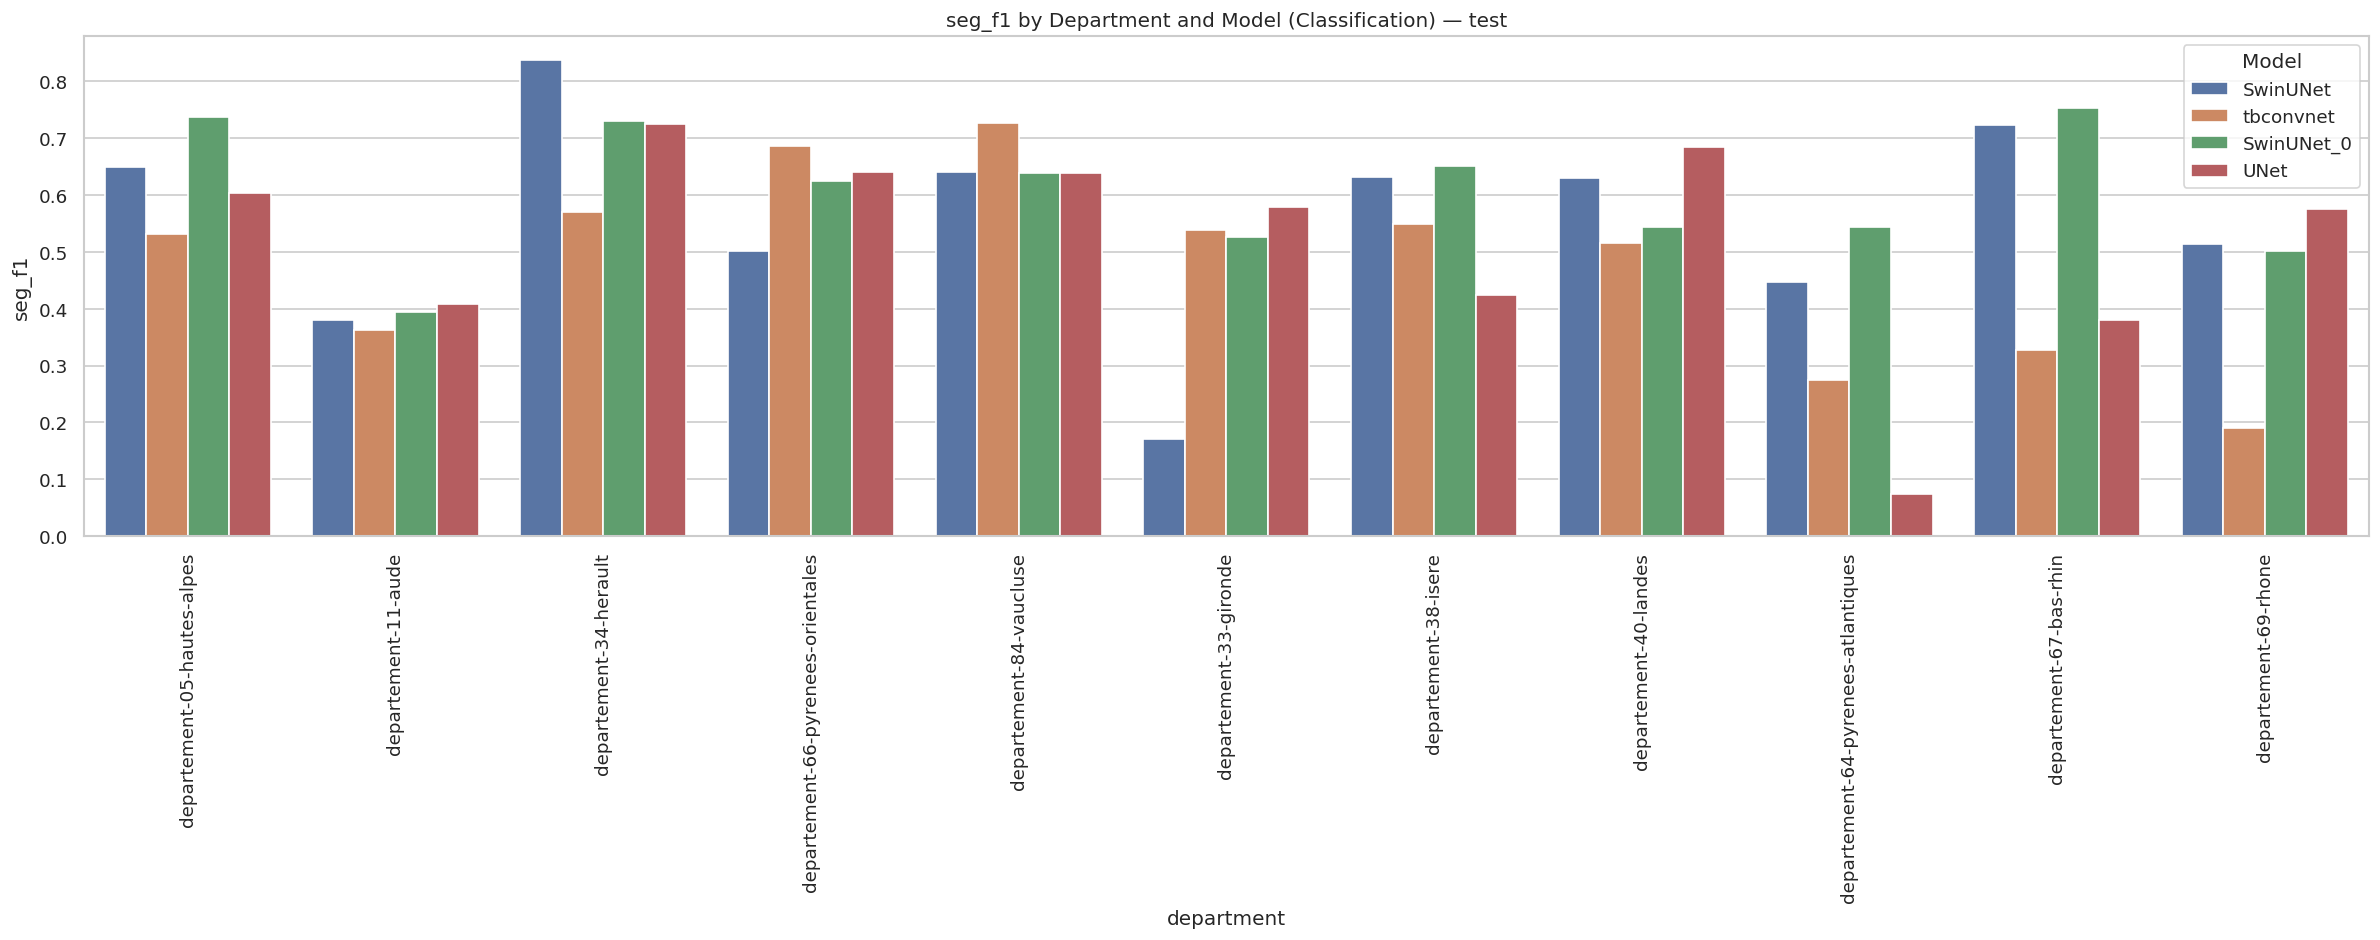

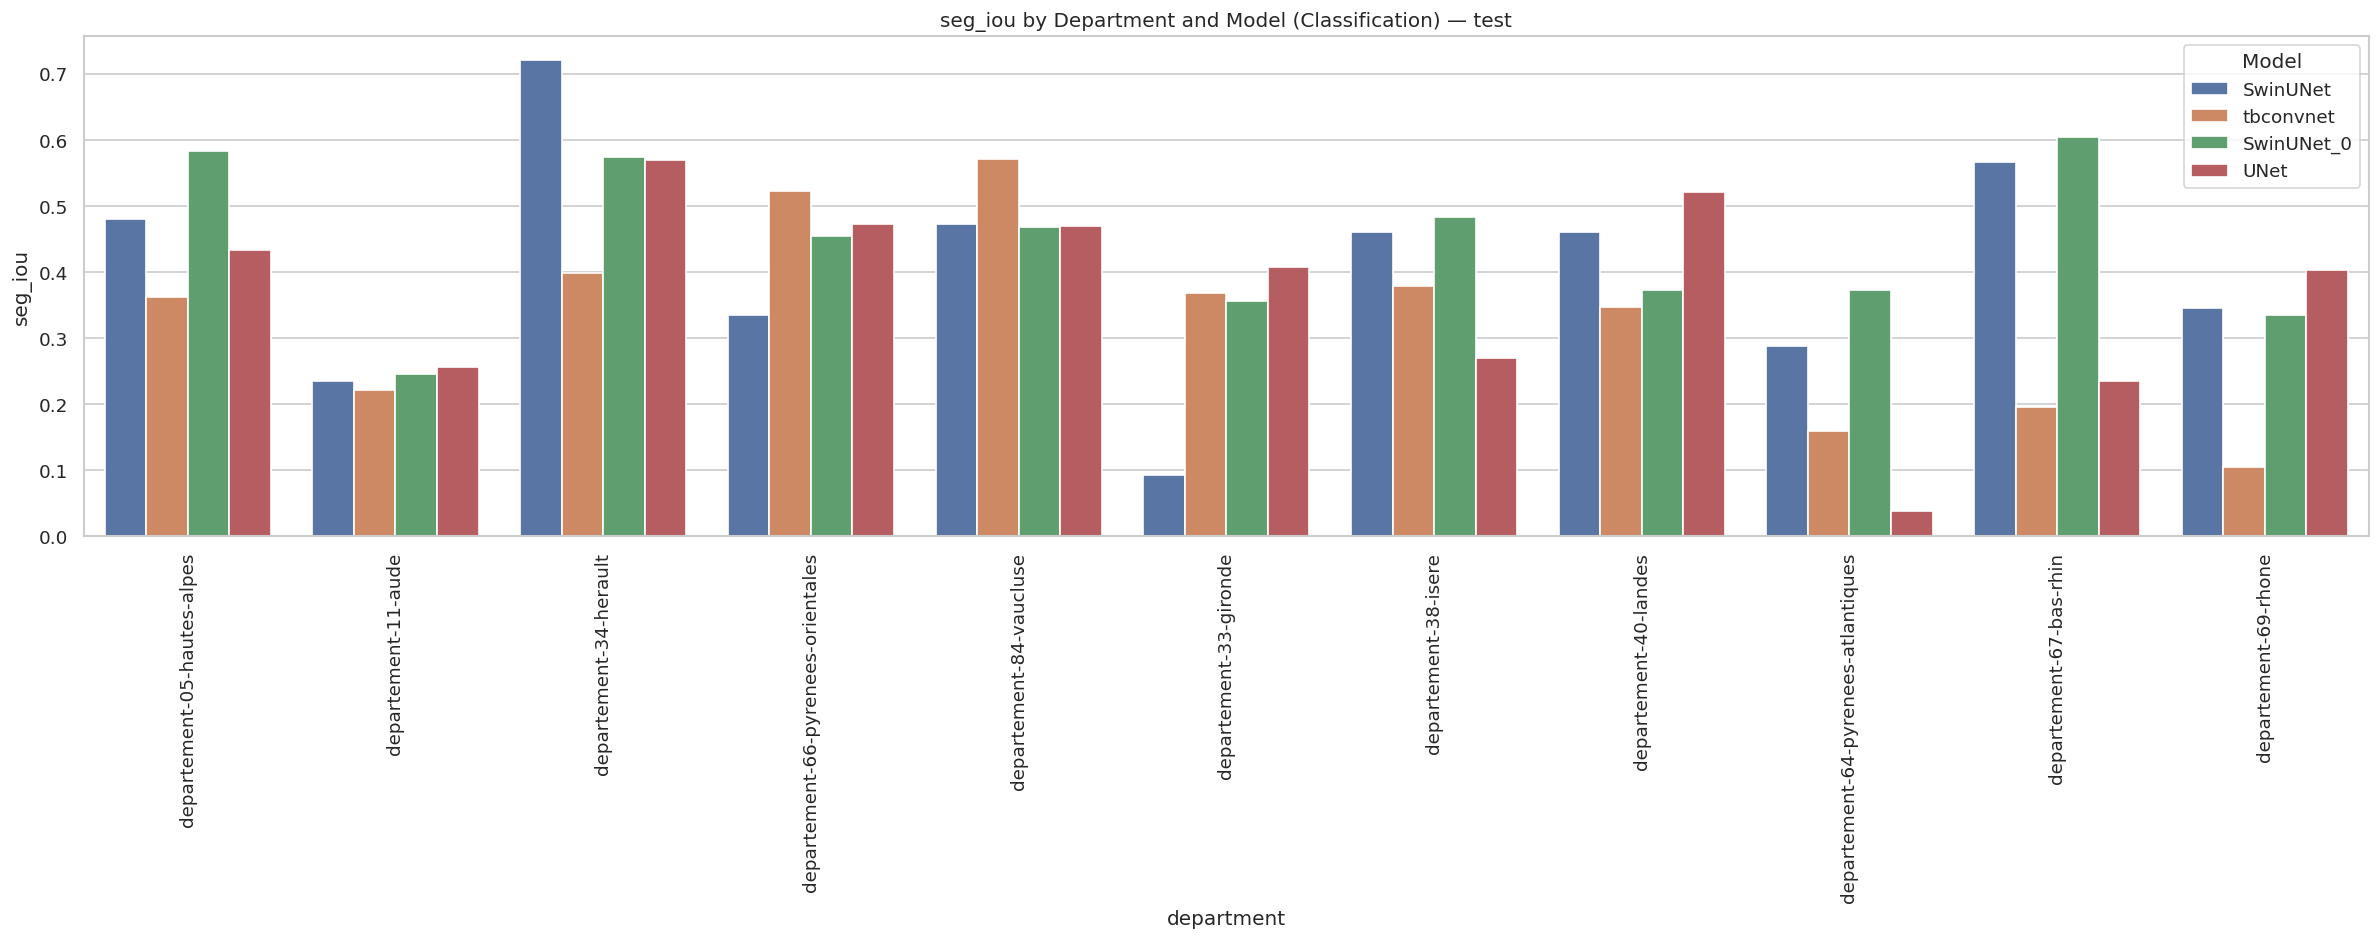


-- Per-department plots for test_set: train --


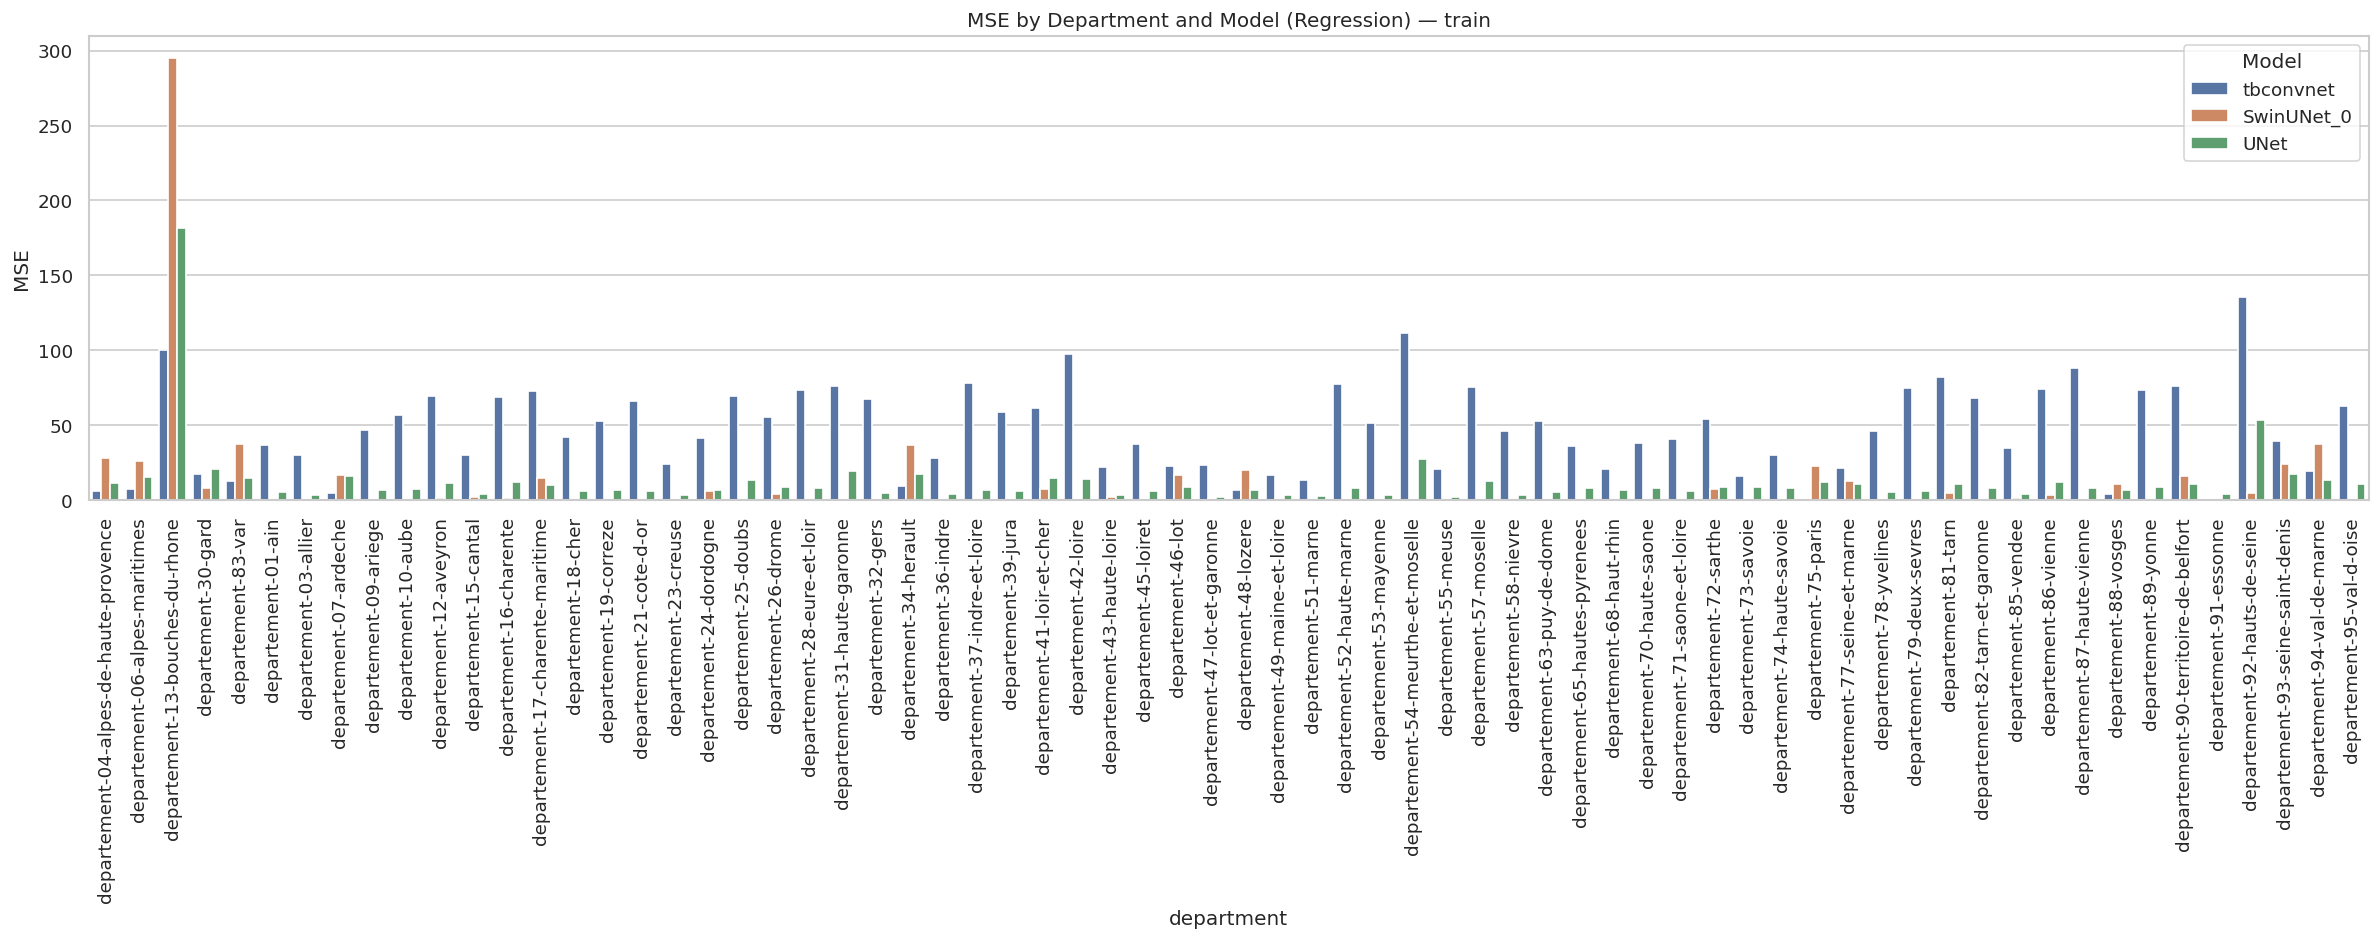

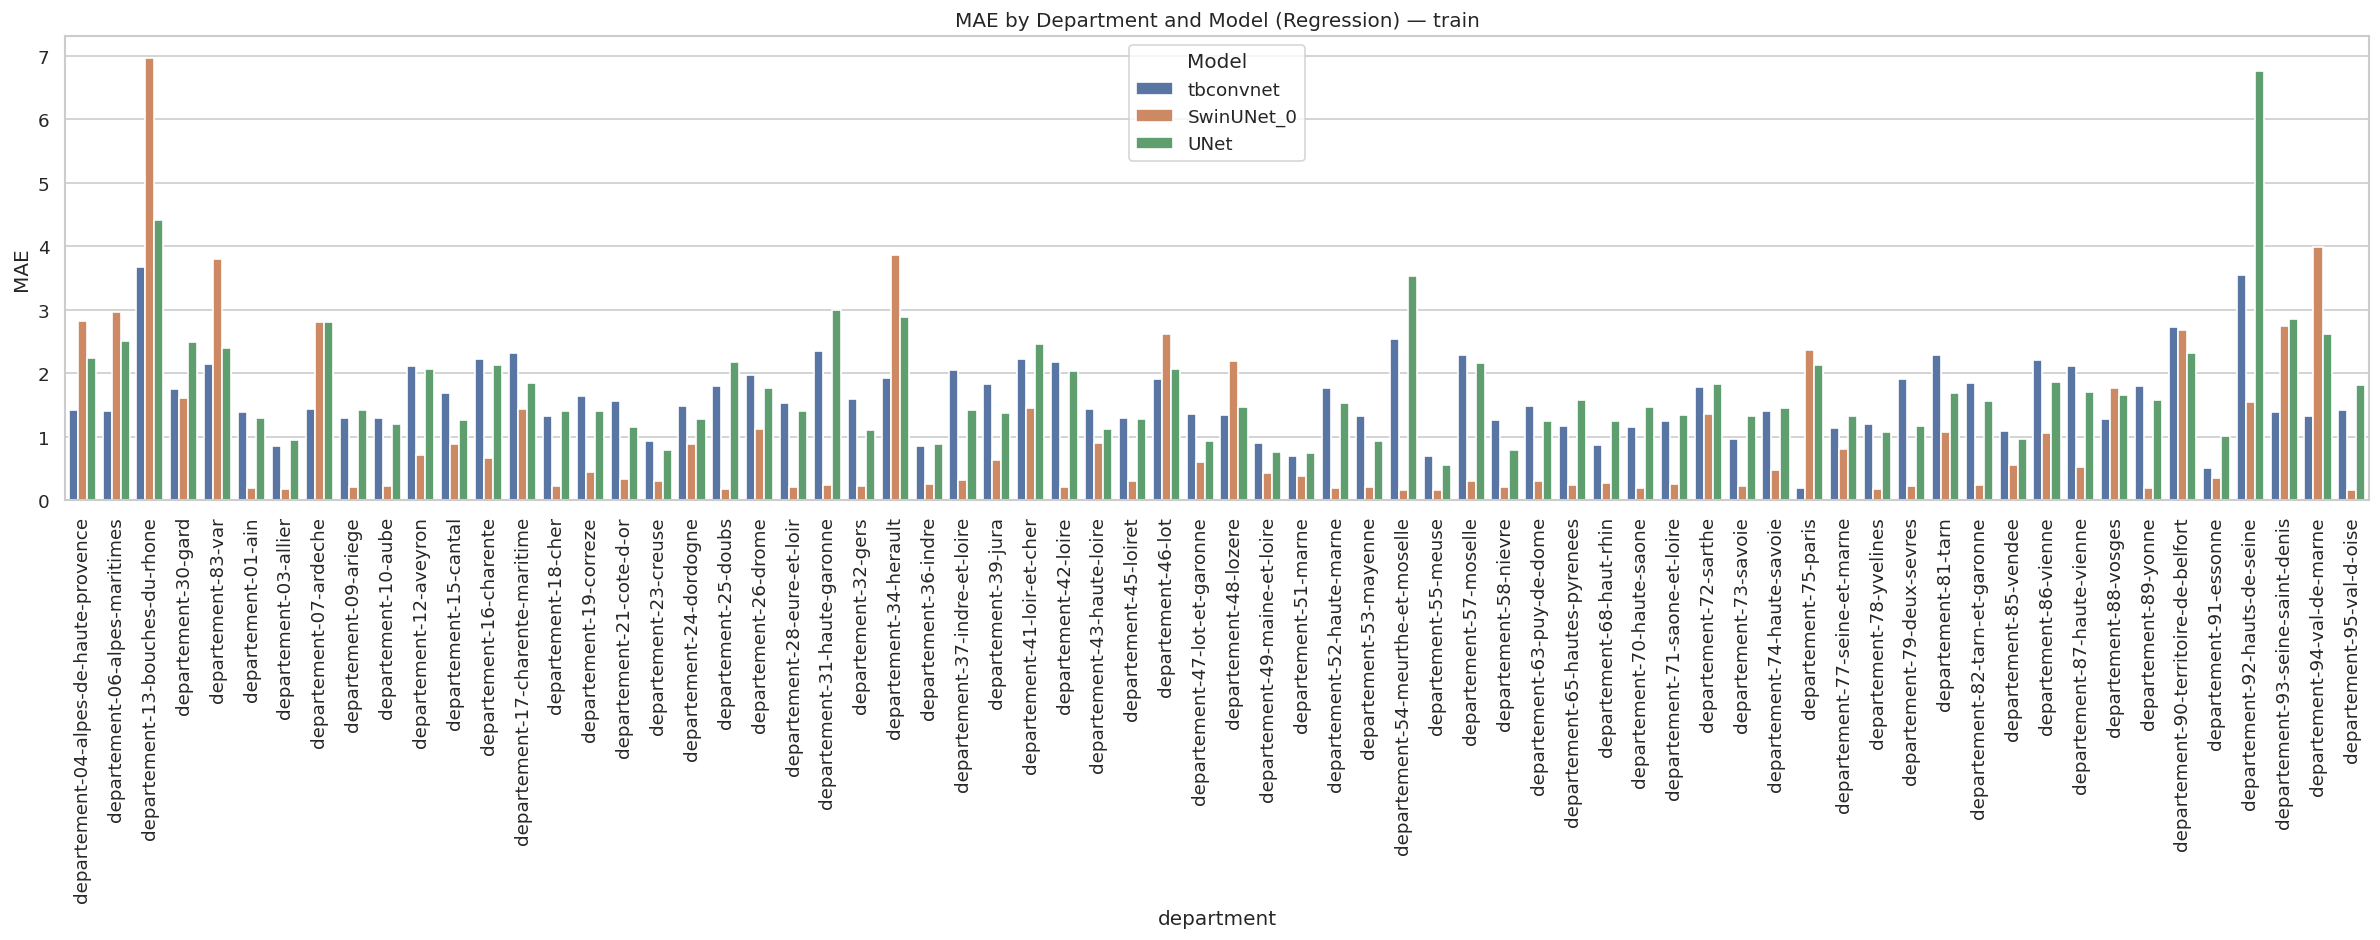

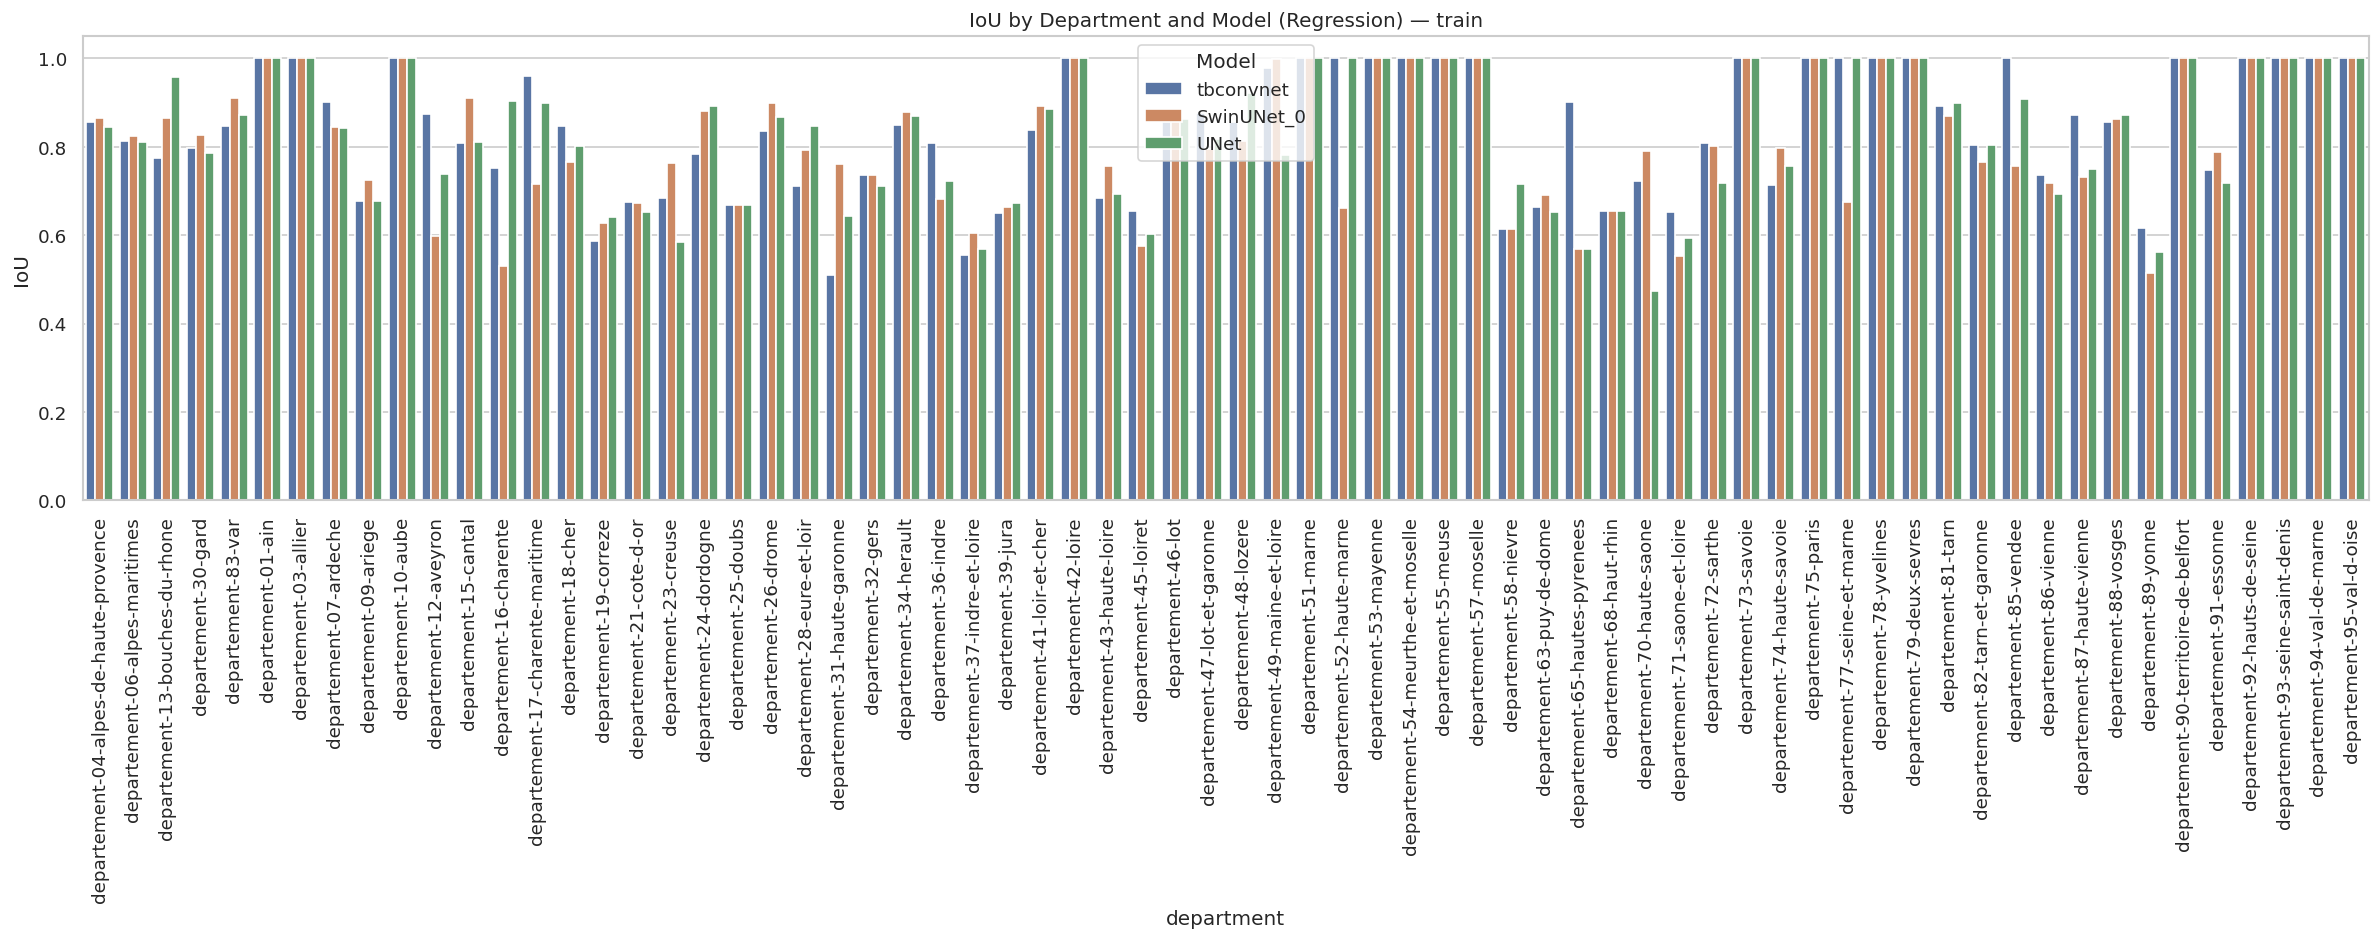

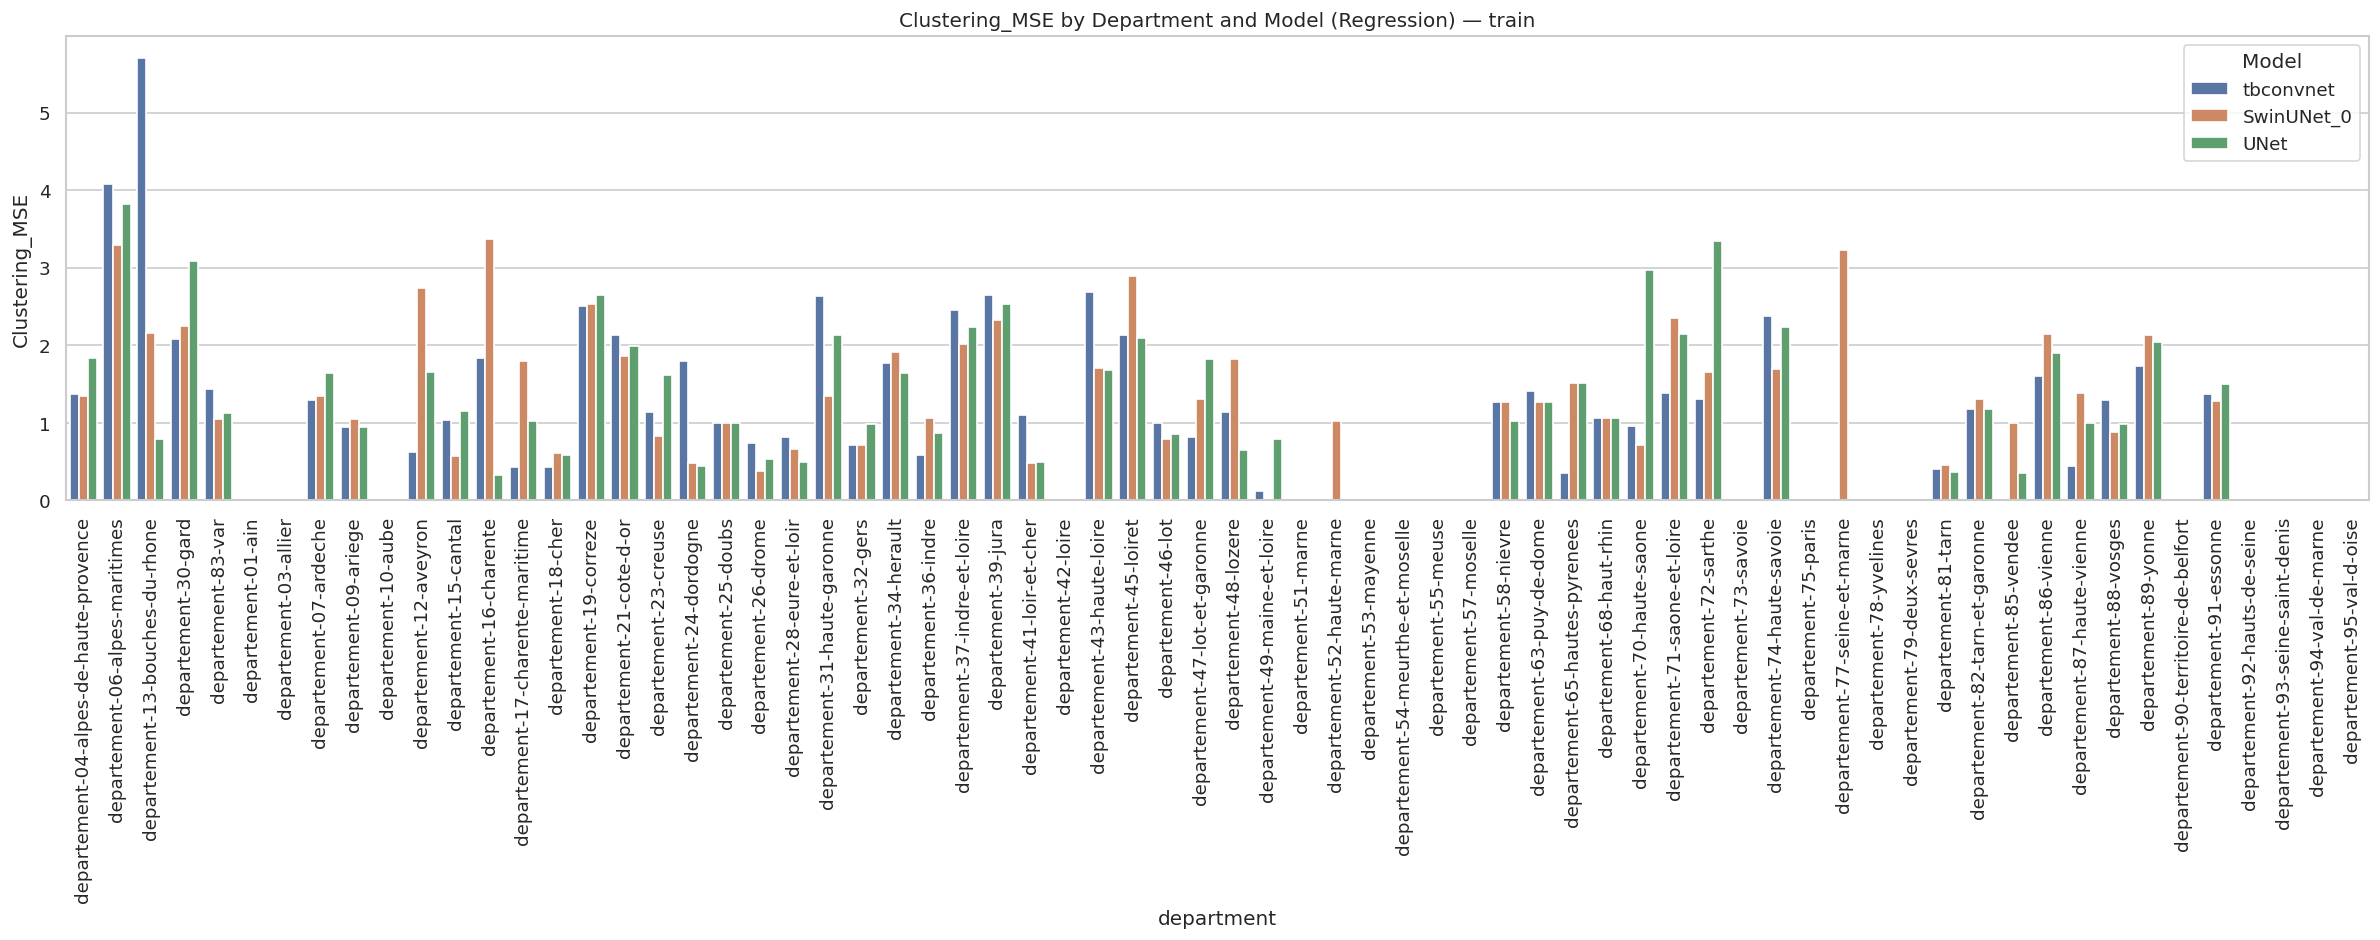

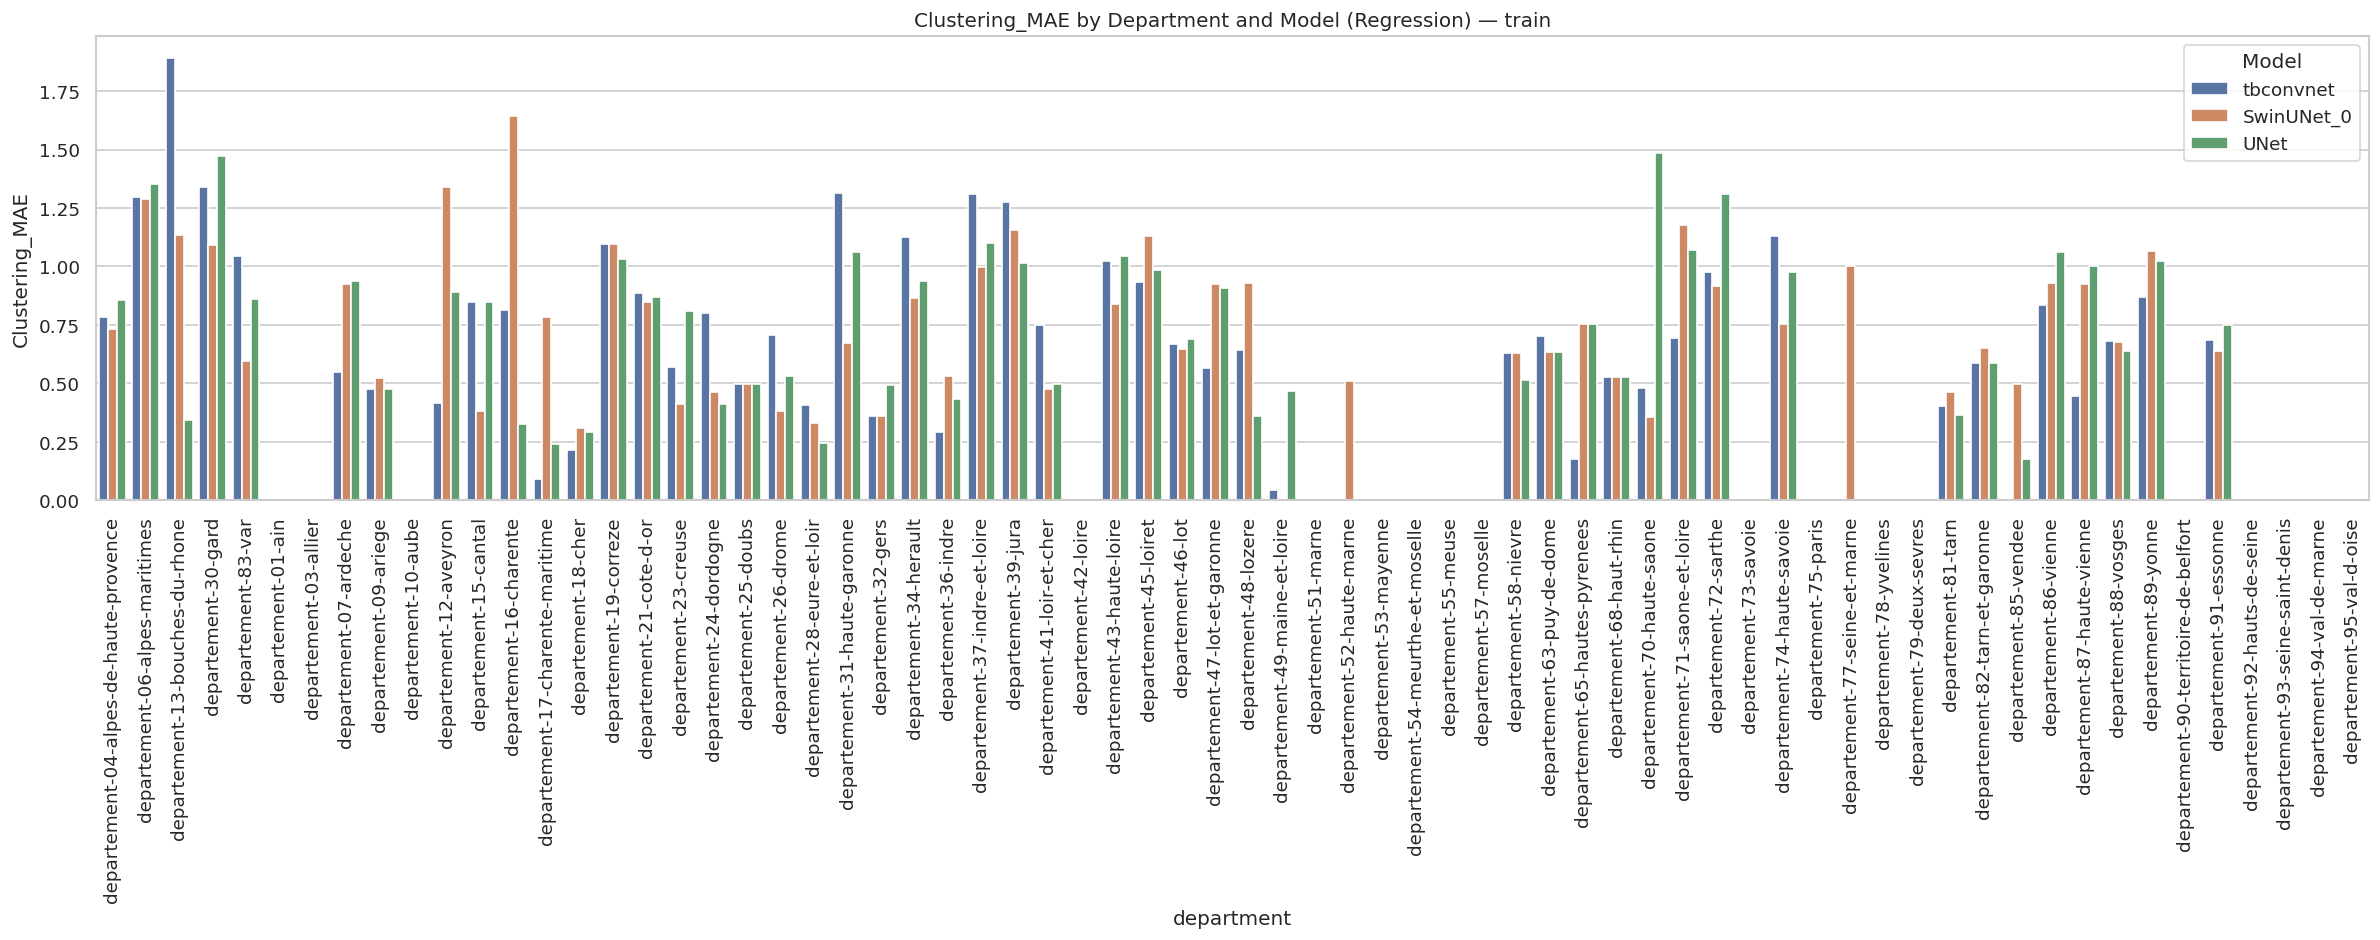

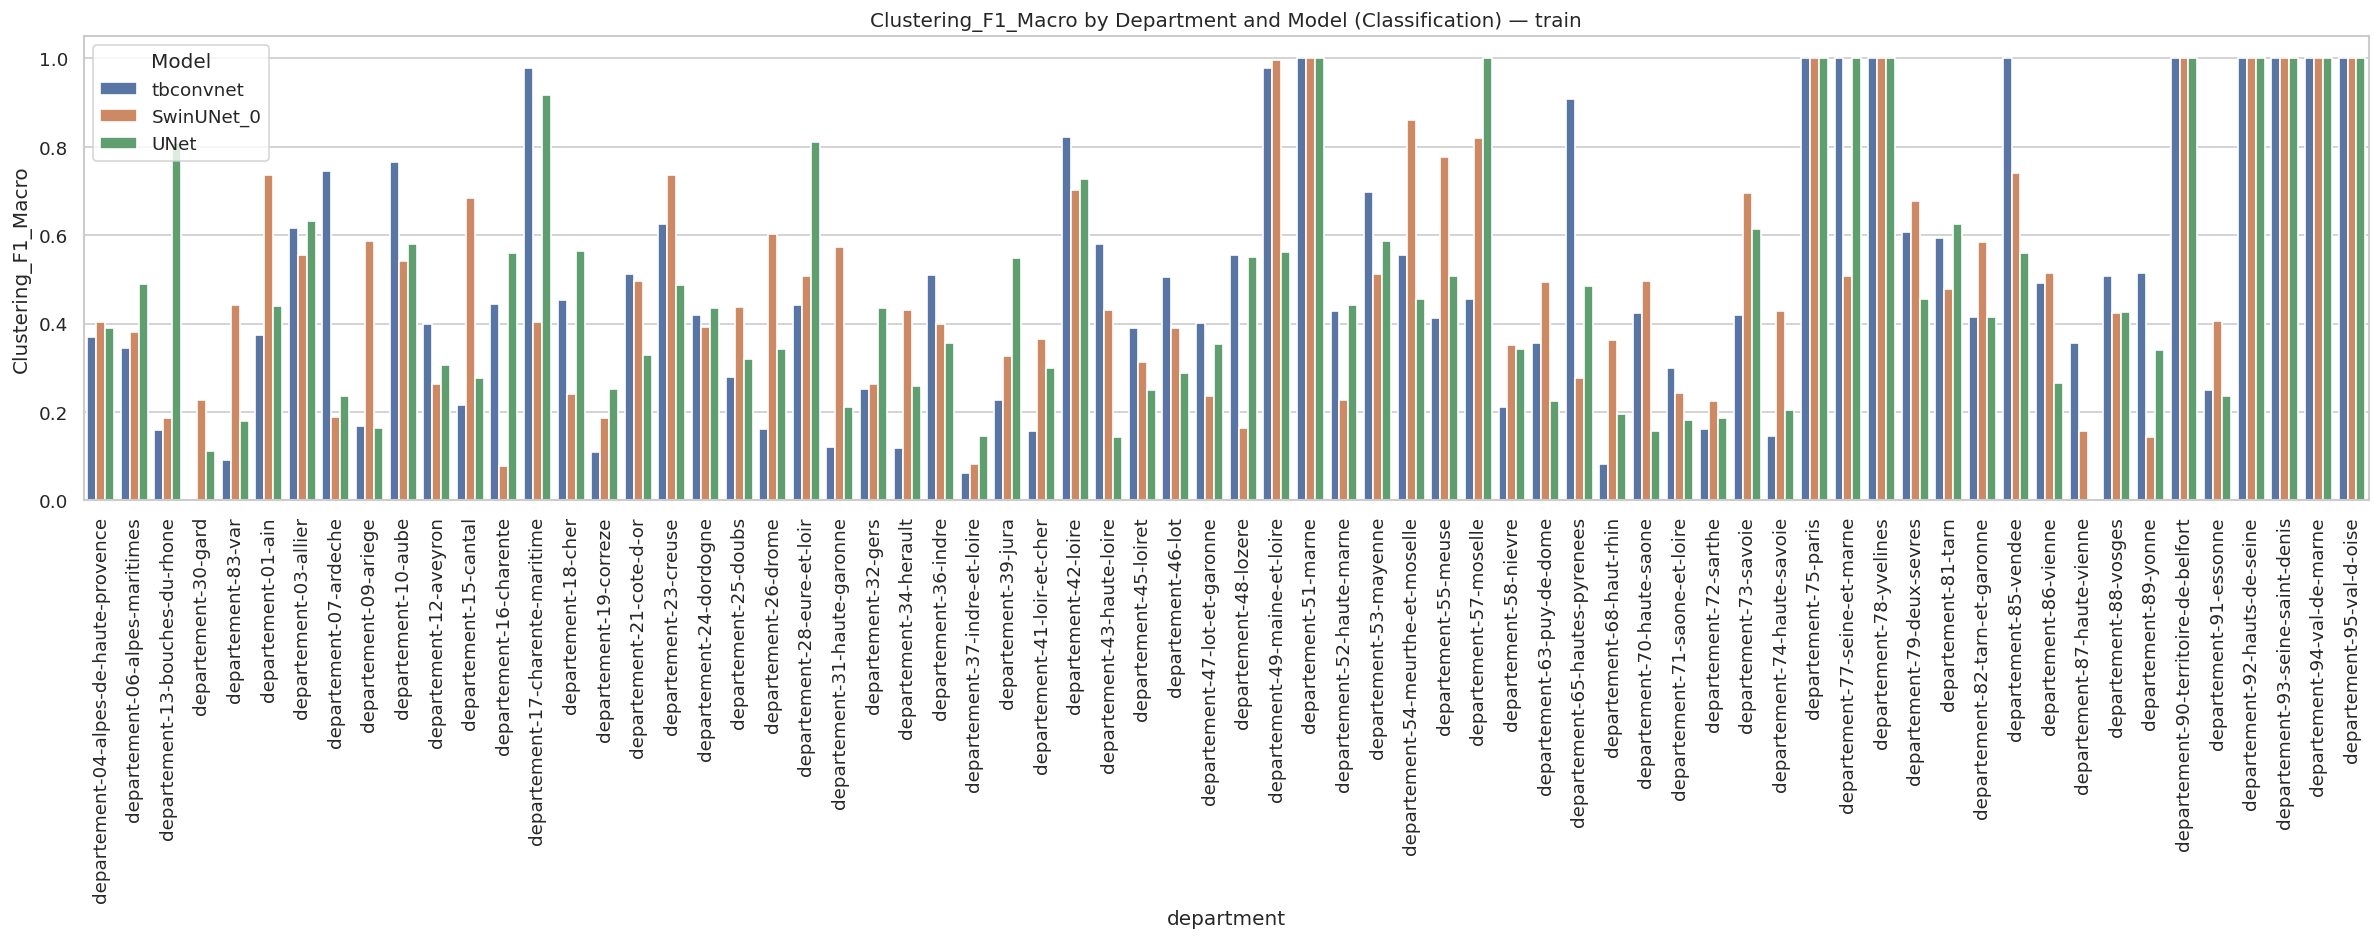

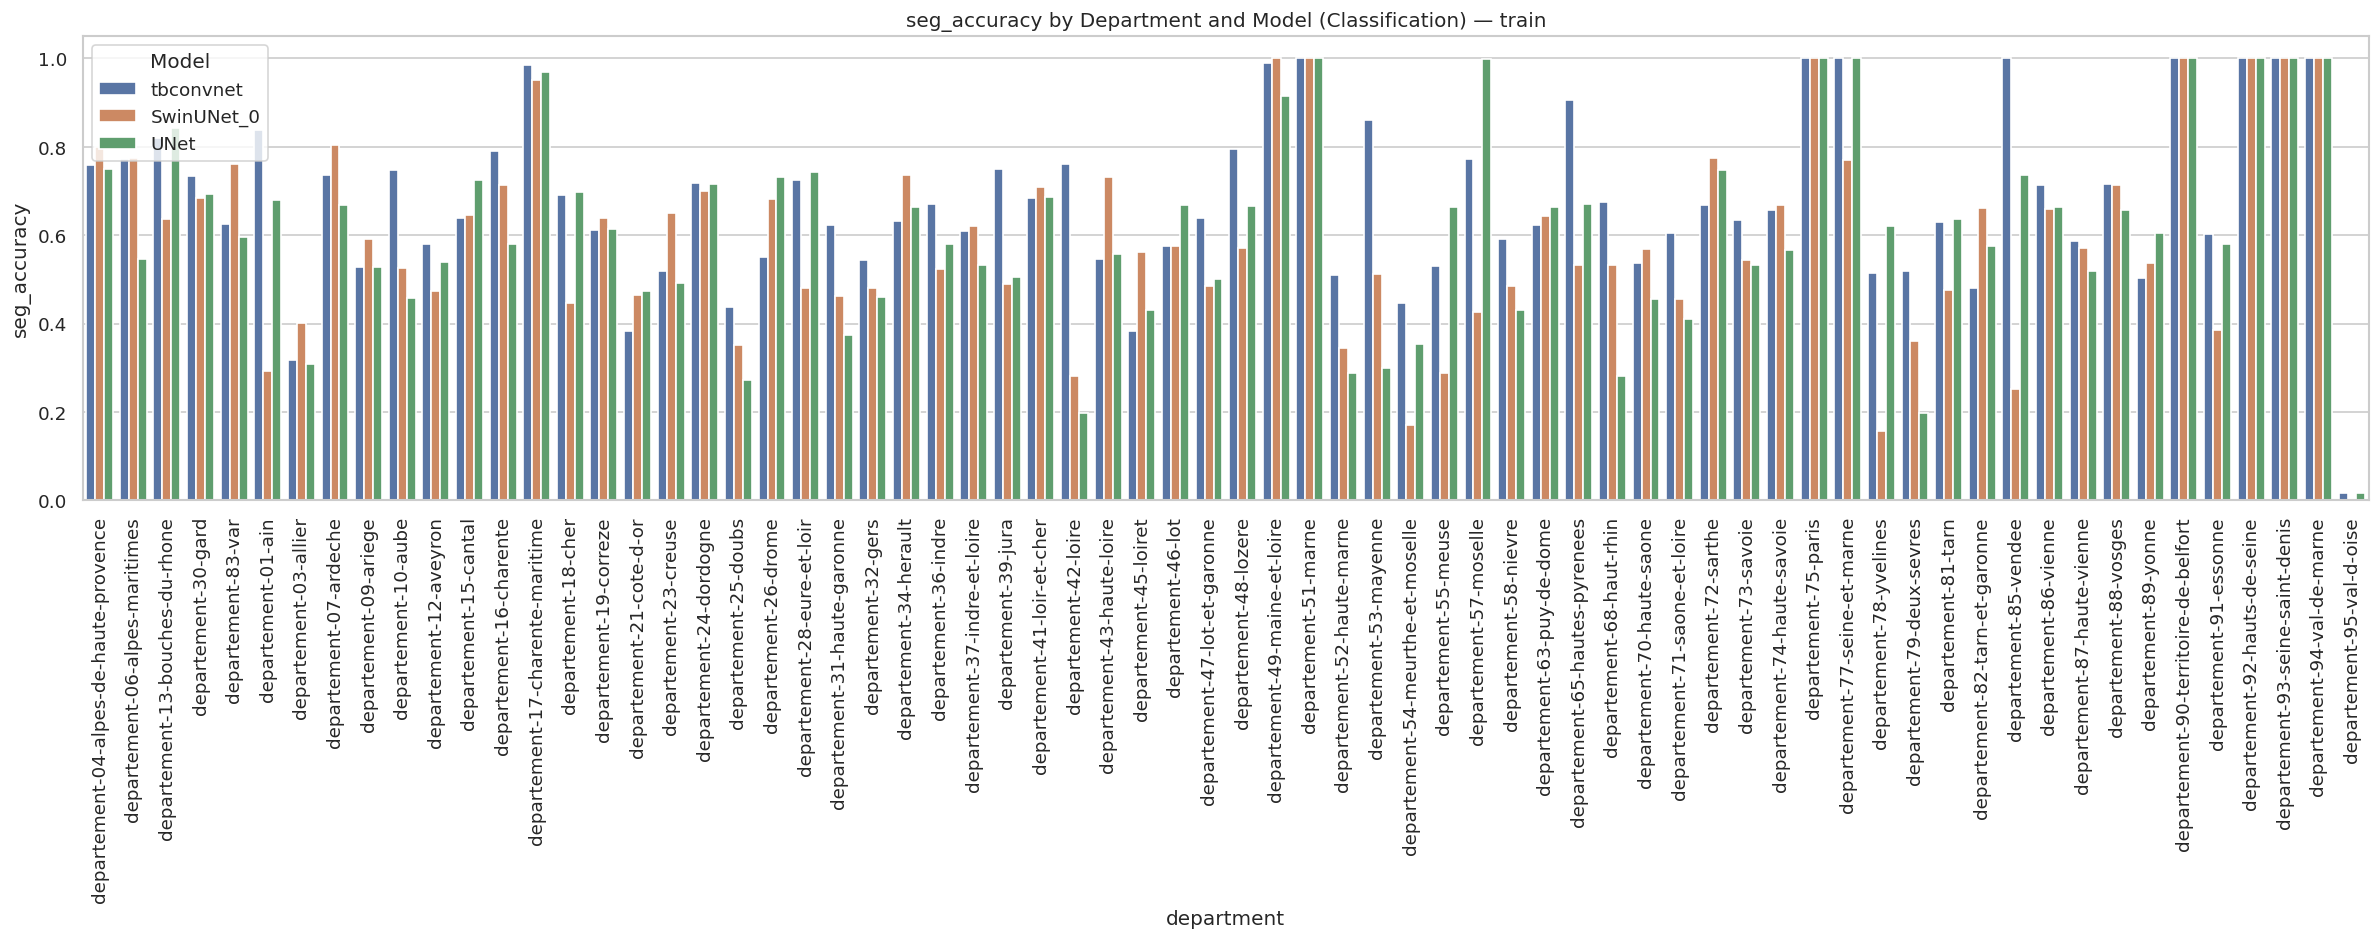

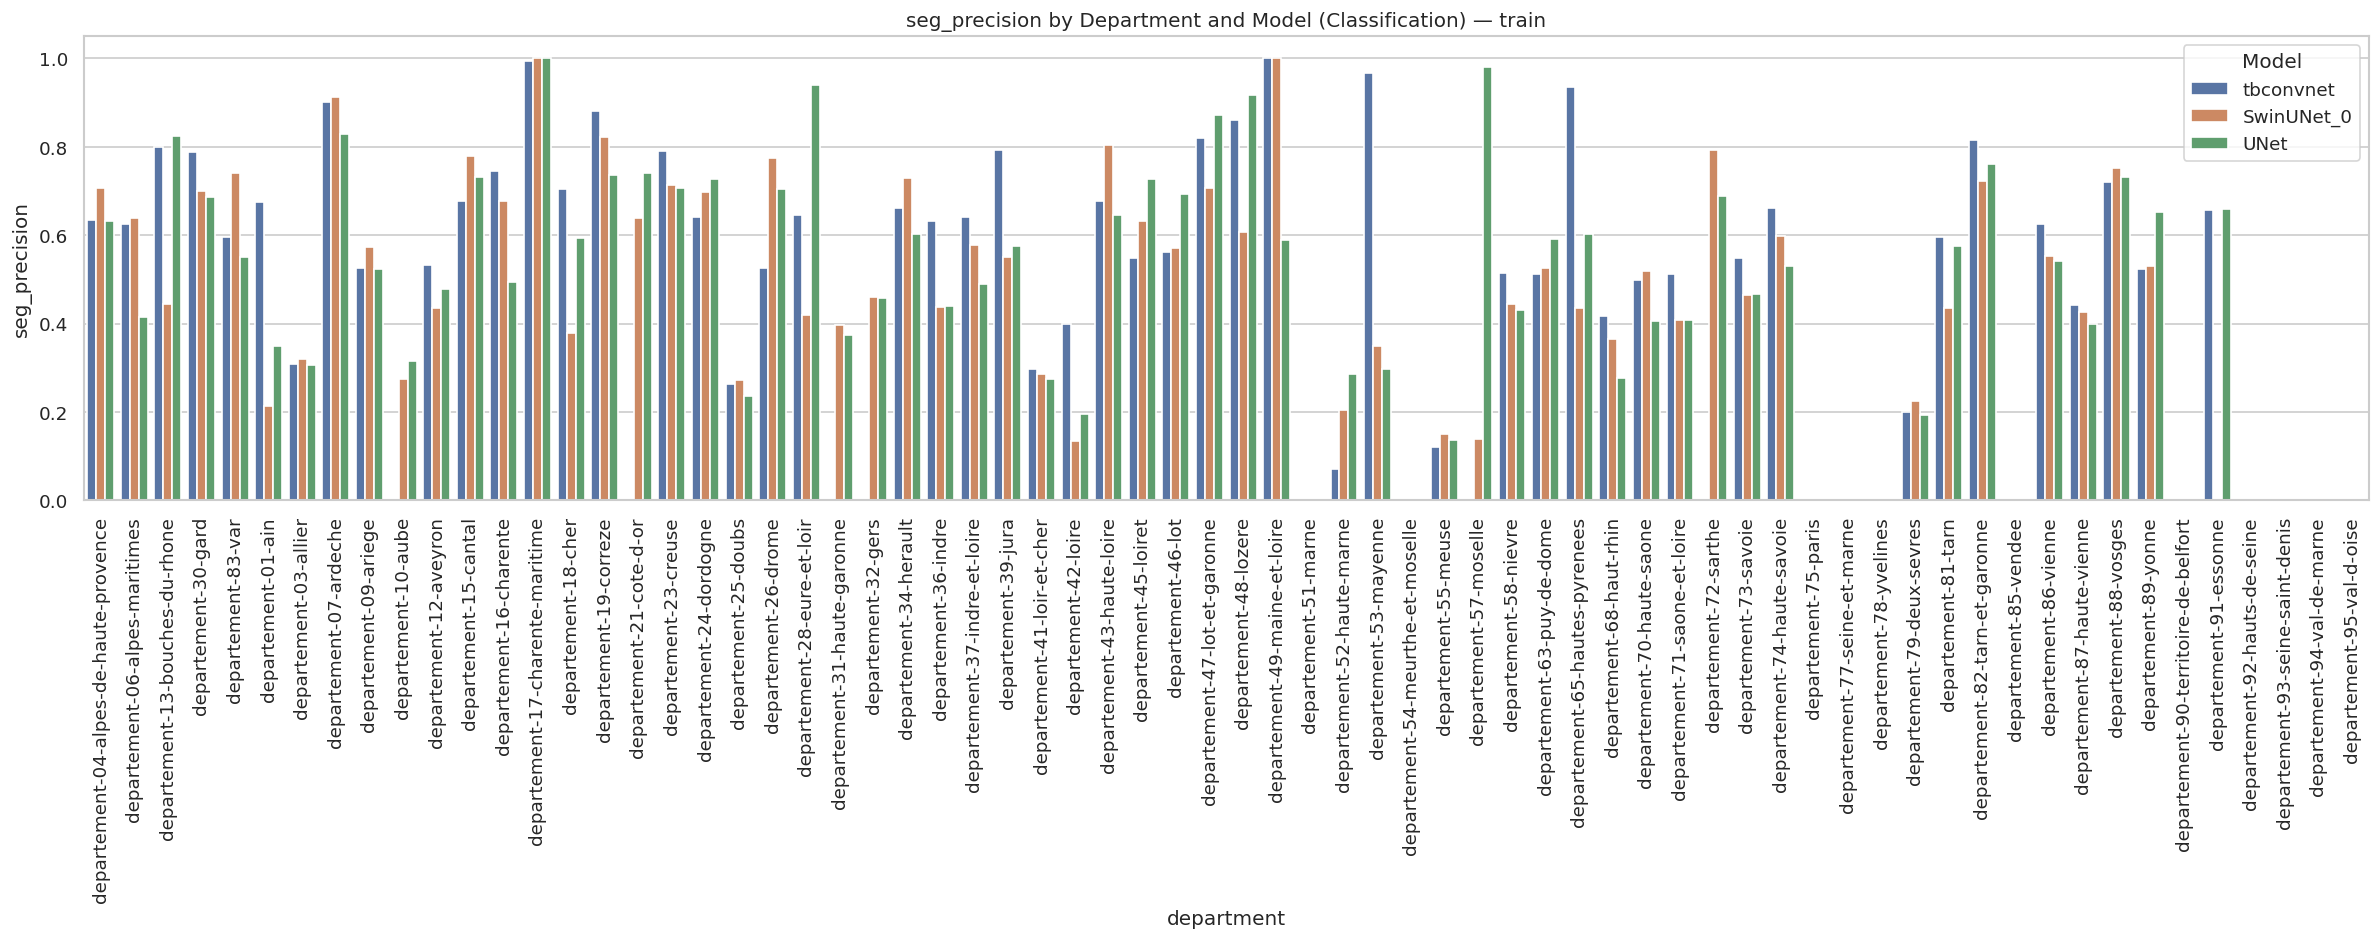

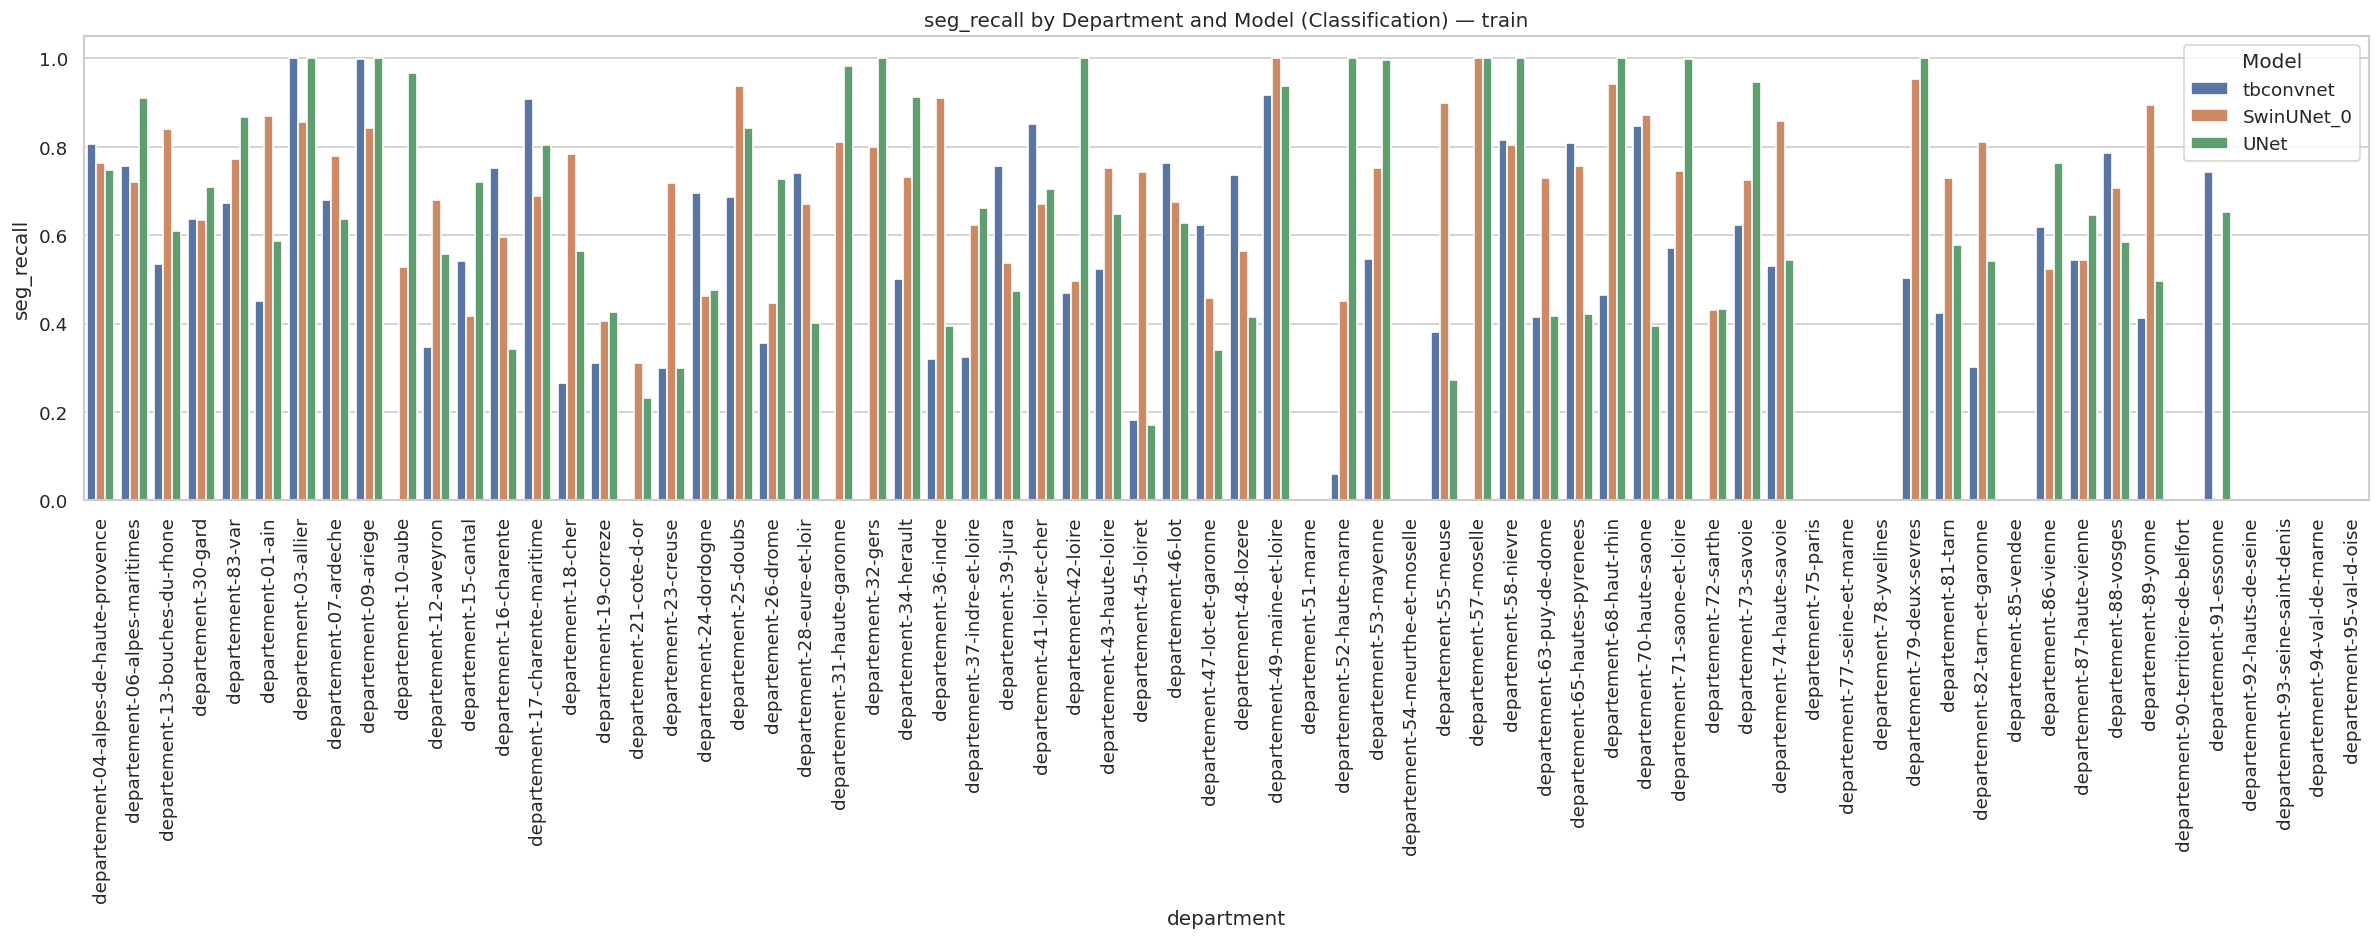

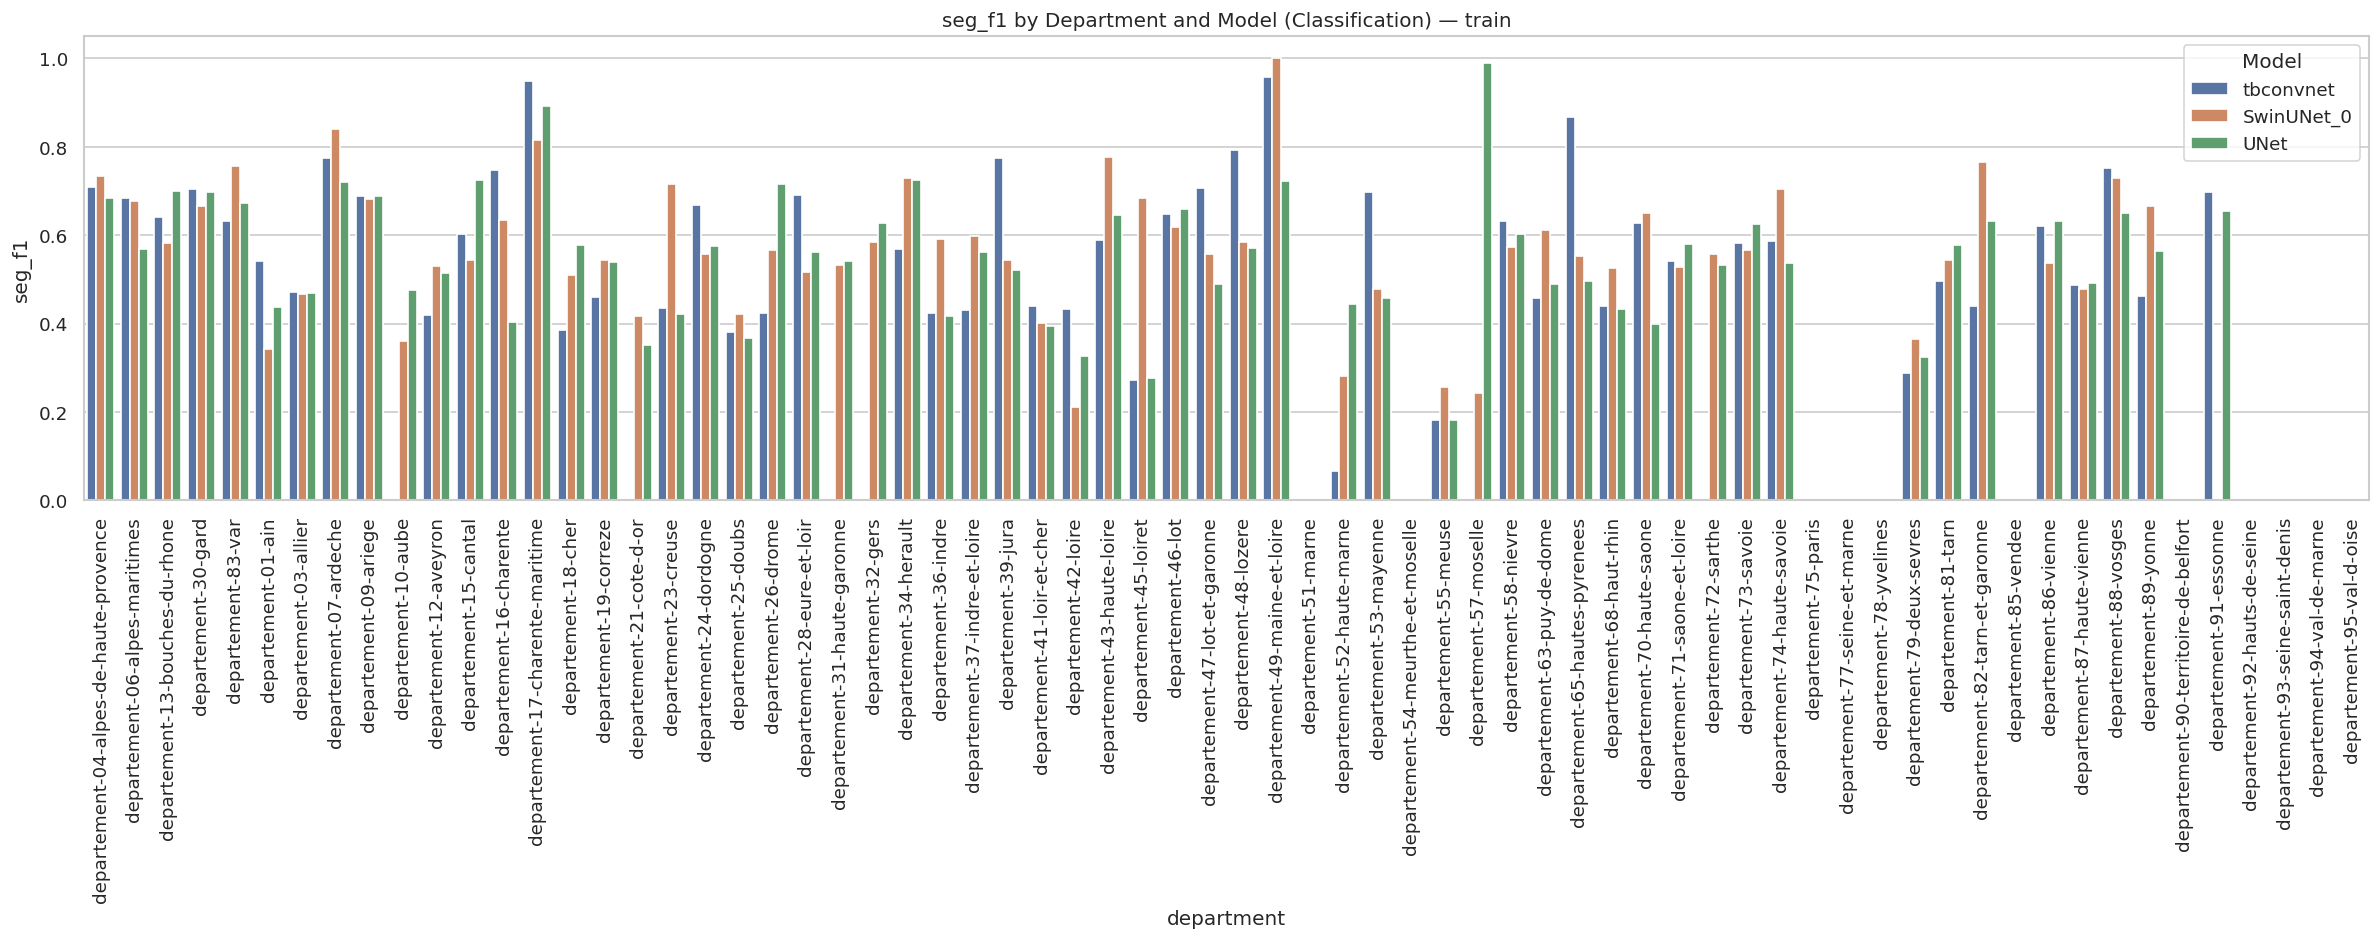

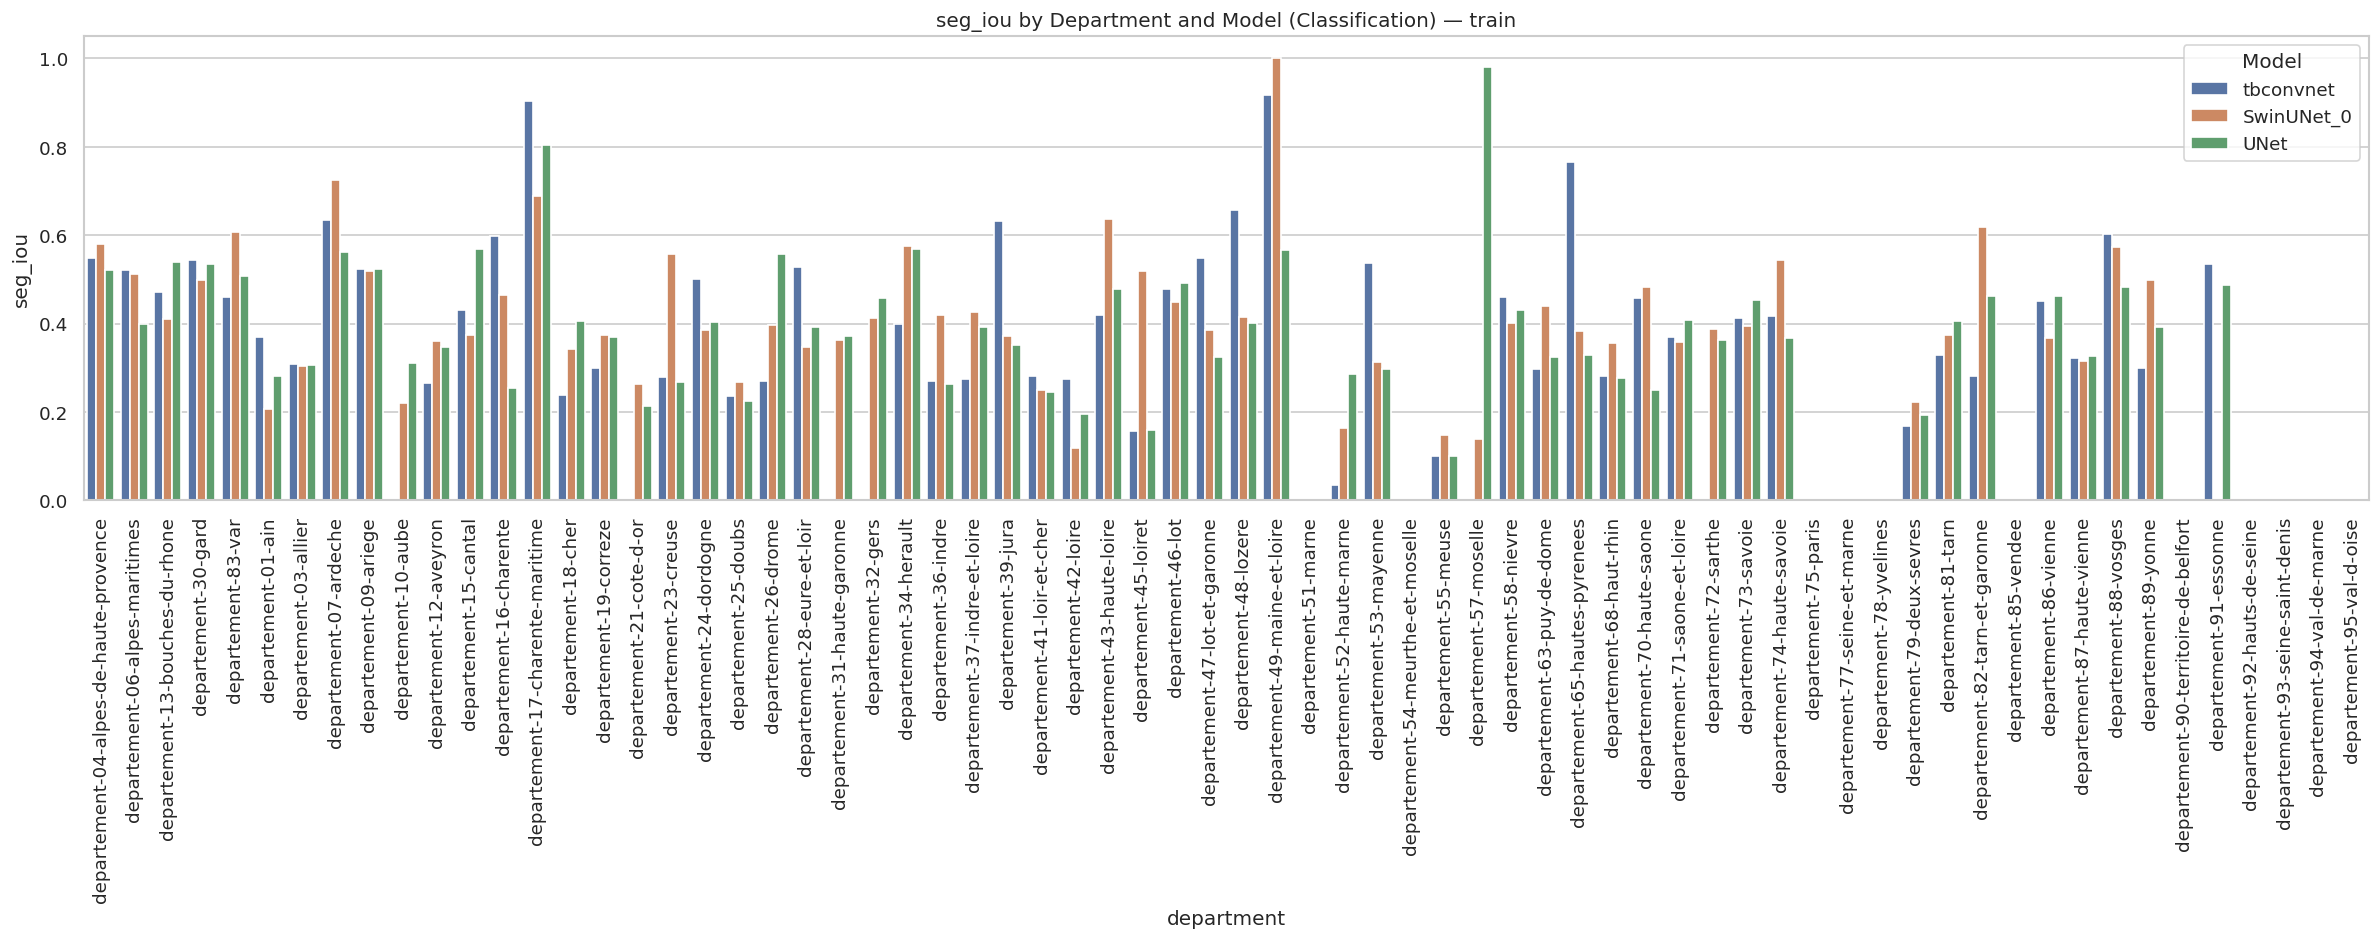

In [8]:
# Per-department plots grouped by metric type and test_set
if not df_scores.empty:
    regression_metrics = ['MSE', 'MAE', 'IoU', 'Clustering_MSE', 'Clustering_MAE']
    classification_metrics = ['Clustering_F1_Macro', 'seg_accuracy', 'seg_precision', 'seg_recall', 'seg_f1', 'seg_iou']
    regression_metrics = [m for m in regression_metrics if m in df_scores.columns]
    classification_metrics = [m for m in classification_metrics if m in df_scores.columns]

    for test_set in df_scores['test_set'].unique():
        df_ts = df_scores[df_scores['test_set'] == test_set]
        print(f'\n-- Per-department plots for test_set: {test_set} --')

        # Regression metrics
        if regression_metrics:
            for metric in regression_metrics:
                plt.figure(figsize=(20, 8))
                sns.barplot(data=df_ts, x='department', y=metric, hue='Model')
                plt.title(f'{metric} by Department and Model (Regression) — {test_set}')
                plt.xticks(rotation=90)
                plt.tight_layout()
                plt.show()

        # Classification metrics
        if classification_metrics:
            for metric in classification_metrics:
                plt.figure(figsize=(20, 8))
                sns.barplot(data=df_ts, x='department', y=metric, hue='Model')
                plt.title(f'{metric} by Department and Model (Classification) — {test_set}')
                plt.xticks(rotation=90)
                plt.tight_layout()
                plt.show()